In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/metadata.csv
/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv


In [2]:
import pandas as pd

train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')
test = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/test.csv')

print(train.shape)
print(test.shape)

train.head()

/tmp/ipykernel_24/2019506285.py:3: DtypeWarning: Columns (38,39) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv')


(138701, 50)
(15000, 49)


,TransactionID,TargetValue,AssetID,ProductConfigID,DataOriginCode,VendorPartnerID,ManufactureYear,OperationalHoursMeter,UtilizationTier,TransactionDate,...,col20,col21,col22,col23,col24,col25,col27,col28,col29,col30
0,1139309,57000.0,117665,88,ACH138,GTX,1997,4640.0,Low,2005-03-26,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Standard,Conventional
1,1139316,26500.0,1001282,4616,ACH138,GTX,2005,508.0,Low,2009-12-18,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1139317,21000.0,772709,1948,ACH138,GTX,1994,11540.0,High,2005-08-26,...,Steel,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN
3,1139322,27000.0,902010,3550,ACH138,GTX,2002,4883.0,High,2006-11-17,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1139333,21500.0,1036259,36014,ACH138,GTX,2009,302.0,Low,2010-08-27,...,Rubber,None or Unspecified,None or Unspecified,None or Unspecified,None or Unspecified,Double,NaN,NaN,NaN,NaN


# Heavy Equipment Selling Price Prediction

## 0. Problem Statement & Objective
The goal of this project is to accurately predict the selling price of heavy equipment at auction based on historical usage, machine specifications, and geographical data. We will utilize advanced feature engineering, target encoding, and ensembling of multiple model families to achieve high accuracy while avoiding data leakage.


## 0.1. Imports

In [3]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import xgboost as xgb



from catboost import CatBoostRegressor
from sklearn.model_selection import KFold
from scipy.stats import chi2_contingency
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import root_mean_squared_error 

# First Time

## 1. Exploratory Data Analysis (EDA)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138701 entries, 0 to 138700
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   TransactionID              138701 non-null  int64  
 1   TargetValue                138701 non-null  float64
 2   AssetID                    138701 non-null  int64  
 3   ProductConfigID            138701 non-null  int64  
 4   DataOriginCode             138701 non-null  object 
 5   VendorPartnerID            138701 non-null  object 
 6   ManufactureYear            138701 non-null  int64  
 7   OperationalHoursMeter      82058 non-null   float64
 8   UtilizationTier            50475 non-null   object 
 9   TransactionDate            138701 non-null  object 
 10  Spec_FullDescriptor        138701 non-null  object 
 11  Spec_BaseClass             138701 non-null  object 
 12  Spec_SubClass              101716 non-null  object 
 13  Spec_ReleaseSeries         32

,TransactionID,TargetValue,AssetID,ProductConfigID,ManufactureYear,OperationalHoursMeter
count,1.387010e+05,138701.000000,1.387010e+05,138701.000000,138701.000000,8.205800e+04
mean,2.186276e+06,41521.874047,1.204814e+06,7286.421922,1891.640853,4.553719e+03
std,1.128497e+06,26361.125948,5.287376e+05,7542.421537,306.992001,2.792204e+04
min,1.139309e+06,7500.000000,8.000000e+00,39.000000,1001.000000,0.000000e+00
25%,1.465754e+06,20500.000000,1.007930e+06,1693.000000,1990.000000,0.000000e+00
50%,1.751884e+06,35000.000000,1.246956e+06,3852.000000,1998.000000,1.620000e+03
75%,2.372139e+06,57000.000000,1.495817e+06,11873.000000,2004.000000,5.001000e+03
max,6.333410e+06,142000.000000,2.478476e+06,37209.000000,2015.000000,1.729600e+06


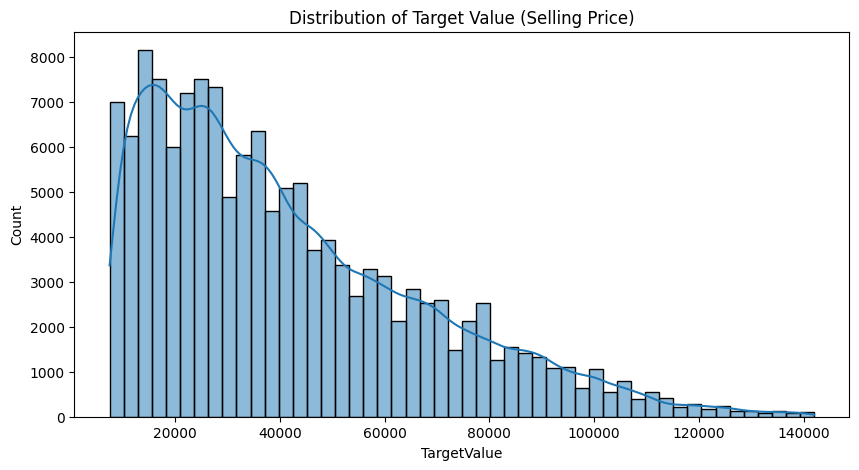

In [4]:
# Check data types and missing values
print(train.info())
print(train.isnull().sum().sort_values(ascending=False).head(10))

# Summary statistics for numerical columns
display(train.describe())

# Check the distribution of the target variable

plt.figure(figsize=(10, 5))
sns.histplot(train['TargetValue'], bins=50, kde=True)
plt.title('Distribution of Target Value (Selling Price)')
plt.show()

##### 1. how come manufacture year be 1001?
##### 2. target variable is highly skewed on right
##### 3. data entries if variuos columns are missing or not?
##### 4. operational hrs and target value are float means continous values possible

In [5]:
print(sorted(train["ManufactureYear"].sort_values().unique())[:20])

[np.int64(1001), np.int64(1920), np.int64(1921), np.int64(1949), np.int64(1951), np.int64(1952), np.int64(1953), np.int64(1954), np.int64(1955), np.int64(1957), np.int64(1958), np.int64(1959), np.int64(1960), np.int64(1961), np.int64(1962), np.int64(1963), np.int64(1964), np.int64(1965), np.int64(1966), np.int64(1967)]


In [6]:
invalid_years = train[train["ManufactureYear"] <= 1950]

print(f"Number of records with ManufactureYear <= 1950: {len(invalid_years)}")

Number of records with ManufactureYear <= 1950: 14740


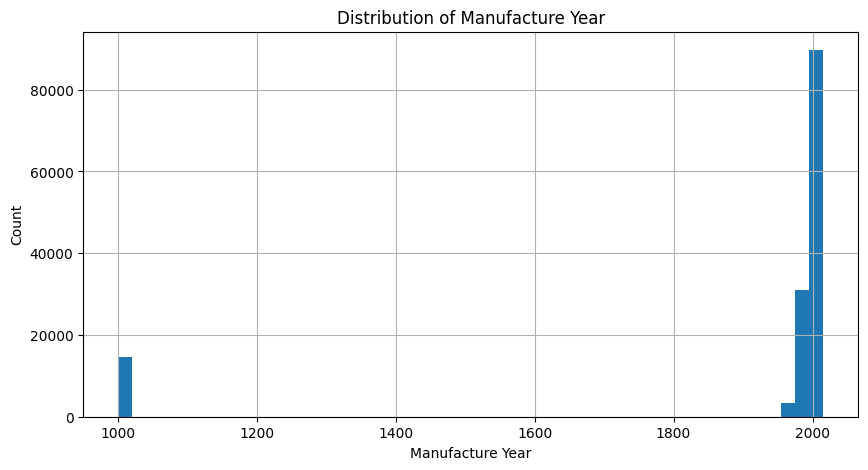

In [7]:
plt.figure(figsize=(10,5))
train["ManufactureYear"].hist(bins=50)
plt.title("Distribution of Manufacture Year")
plt.xlabel("Manufacture Year")
plt.ylabel("Count")
plt.show()

In [8]:
missing_df = pd.DataFrame({
    'Missing Count': train.isnull().sum(),
    'Missing %': (train.isnull().sum() / len(train) * 100)
})

missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

display(missing_df.head(10))

,Missing Count,Missing %
col18,138635,99.952416
col19,138635,99.952416
col4,128320,92.515555
col5,128320,92.515555
col28,123742,89.214930
col27,123742,89.214930
col30,119829,86.393753
col29,119829,86.393753
col14,115296,83.125572
col11,115296,83.125572


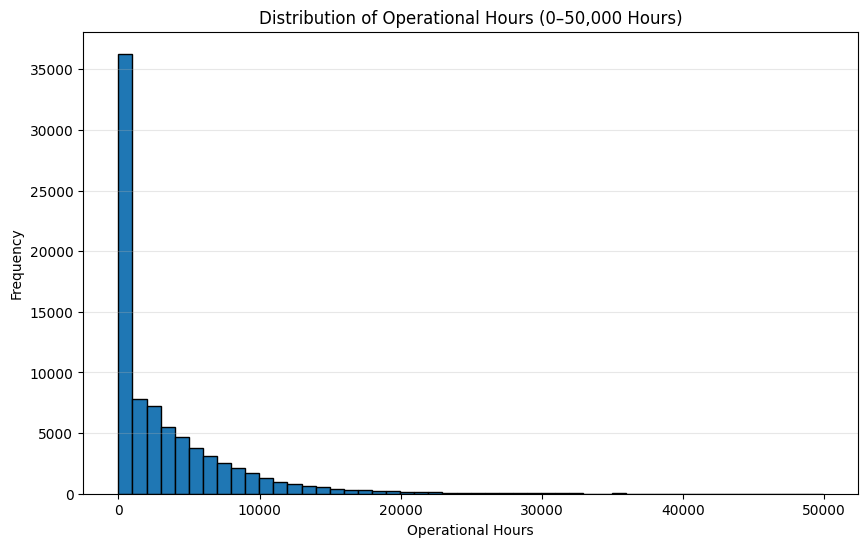

In [9]:
plt.figure(figsize=(10, 6))
plt.hist(
    train.loc[train['OperationalHoursMeter'] <= 50000, 'OperationalHoursMeter'].dropna(),
    bins=50,
    edgecolor='black'
)

plt.title('Distribution of Operational Hours (0–50,000 Hours)')
plt.xlabel('Operational Hours')
plt.ylabel('Frequency')

plt.grid(axis='y', alpha=0.3)
plt.show()

## 2. Data cleaning

In [10]:
def engineer_features(df, is_train=True):
    df_feat = df.copy()
    
    # Replace years before 1950 with NaN
    df_feat['ManufactureYear'] = df_feat['ManufactureYear'].apply(lambda x: np.nan if x <= 1950 else x)
    
    # Date columns
    df_feat['TransactionDate'] = pd.to_datetime(df_feat['TransactionDate'])
    df_feat['TransactionYear'] = df_feat['TransactionDate'].dt.year
    df_feat['TransactionMonth'] = df_feat['TransactionDate'].dt.month
    df_feat['TransactionDay'] = df_feat['TransactionDate'].dt.day
    df_feat['TransactionDayOfWeek'] = df_feat['TransactionDate'].dt.dayofweek
    
    # Calculate the age of the machine
    df_feat['EquipmentAgeAtSale'] = df_feat['TransactionYear'] - df_feat['ManufactureYear']
    df_feat['EquipmentAgeAtSale'] = df_feat['EquipmentAgeAtSale'].apply(lambda x: np.nan if x < 0 else x)
    
    # Handle Operational Hours Outliers
    hour_cap = 30000 
    df_feat['OperationalHoursMeter'] = df_feat['OperationalHoursMeter'].clip(upper=hour_cap)
    df_feat['Hours_Is_Missing'] = df_feat['OperationalHoursMeter'].isnull().astype(int)
    
    # Drop empty columns and IDs (greater than 99% + assetID)
    cols_to_drop = ['col18', 'col19', 'TransactionID', 'TransactionDate', 'AssetID']
    df_feat = df_feat.drop(columns=[col for col in cols_to_drop if col in df_feat.columns])
    
    # Fill missing values for object/categorical columns with a specific string
    cat_cols = df_feat.select_dtypes(include=['object']).columns
    df_feat[cat_cols] = df_feat[cat_cols].fillna('Missing_Value')

    # Convert all string columns explicitly to 'category' type
    for col in cat_cols:
        df_feat[col] = df_feat[col].astype('category')

    # Log transform
    if is_train:
        y = np.log1p(df_feat['TargetValue'])
        X = df_feat.drop(columns=['TargetValue'])
        return X, y
    else:
        return df_feat

X_train, y_train = engineer_features(train, is_train=True)
X_test = engineer_features(test, is_train=False)

print("--- Base Cleaning Complete ---")
print(f"Engineered Train Shape: {X_train.shape}")
print(f"Engineered Test Shape:  {X_test.shape}")

--- Base Cleaning Complete ---
Engineered Train Shape: (138701, 50)
Engineered Test Shape:  (15000, 50)


#### We saw that some manufacture years were less than 1950 (like the dummy year 1001). This will create a negative impact and confuse the model, so we made them NaN. Next, we extracted useful date features like the transaction year and month. We also handled the operational hours outliers by capping them at 30,000 to keep the data stable. Finally, we took the log of our target price because the competition requires RMSLE.


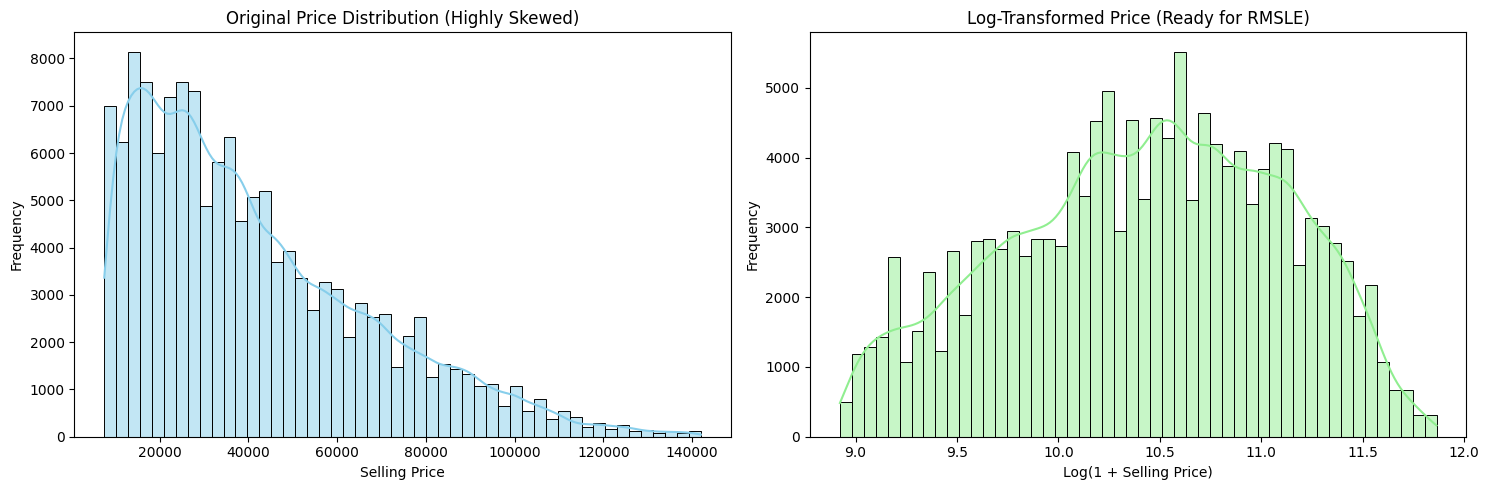

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: The original, highly skewed TargetValue
sns.histplot(train['TargetValue'], bins=50, ax=axes[0], color='skyblue', kde=True)
axes[0].set_title('Original Price Distribution (Highly Skewed)')
axes[0].set_xlabel('Selling Price')
axes[0].set_ylabel('Frequency')

# Plot 2: The log-transformed TargetValue (y_train)
sns.histplot(y_train, bins=50, ax=axes[1], color='lightgreen', kde=True)
axes[1].set_title('Log-Transformed Price (Ready for RMSLE)')
axes[1].set_xlabel('Log(1 + Selling Price)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

#### target variable is highly skewed on right becuase of some expensive machines so to make a bell curve we added log transformation so that rmsle can be minimized.

## 1.1 EDA again

##### Now that our base features are clean and perfectly aligned. 
##### now lets check that if the machine lose value as a straight line, or if there is high usage of machin always low price is tehre, or do the train and test sets cover the same timeperiods otherwise is it producing future?
##### lets check if type of Cabin and the Hydraulics (col10) work together to affect the price
##### then lets check if missing data for the machine's operating hours actually means anything.

In [12]:
print("--- Nonlinear Depreciation Check ---")
train['Age_Group'] = pd.qcut(X_train['EquipmentAgeAtSale'].dropna(), q=5, labels=['Very New', 'New', 'Mid-Age', 'Old', 'Very Old'])
print(train.groupby('Age_Group', observed=False)['TargetValue'].median())

print("\n--- hour analysis ---")
train['Age'] = X_train['EquipmentAgeAtSale']
train['Hours'] = X_train['OperationalHoursMeter']
print("Median price of New Machine with High Hours vs Low Hours:")
print(train[train['Age'] <= 5].groupby(train['Hours'] > 5000, observed=False)['TargetValue'].median())
print("\nMedian price of Old Machine with High Hours vs Low Hours:")
print(train[train['Age'] > 15].groupby(train['Hours'] > 5000, observed=False)['TargetValue'].median())

print("\n--- timeperiod ---")
print("Train Transaction Years distribution:")
print(X_train['TransactionYear'].value_counts().sort_index())
print("\nTest Transaction Years distribution:")
print(X_test['TransactionYear'].value_counts().sort_index())

print("\n--- Interaction Analysis: Cabin Type vs Hydraulics (col10) ---")
interaction_table = pd.crosstab(
    train['CabinType'], 
    train['col10'].fillna('Missing'), 
    values=train['TargetValue'], 
    aggfunc='median'
)
print(interaction_table)


print("\n--- Missing Hours vs Price Distribution Analysis ---")
print("Median Price when OperationalHoursMeter is MISSING:")
print(train[train['OperationalHoursMeter'].isnull()]['TargetValue'].median())

print("\nMedian Price when OperationalHoursMeter is PRESENT:")
print(train[train['OperationalHoursMeter'].notnull()]['TargetValue'].median())


--- Nonlinear Depreciation Check ---
Age_Group
Very New    56000.0
New         43000.0
Mid-Age     36000.0
Old         30000.0
Very Old    24000.0
Name: TargetValue, dtype: float64

--- hour analysis ---
Median price of New Machine with High Hours vs Low Hours:
Hours
False    51000.0
True     63000.0
Name: TargetValue, dtype: float64

Median price of Old Machine with High Hours vs Low Hours:
Hours
False    22500.0
True     25000.0
Name: TargetValue, dtype: float64

--- timeperiod ---
Train Transaction Years distribution:
TransactionYear
1990      577
1991      518
1992      589
1993      560
1994      657
1995     1338
1996     1416
1997     1678
1998     1949
1999     2910
2000     2735
2001     3814
2002     3833
2003     3911
2004     3452
2005     5303
2006     5746
2007     6142
2008    11985
2009    16809
2010    21333
2011    17880
2012    18472
2013     5094
Name: count, dtype: int64

Test Transaction Years distribution:
TransactionYear
1990      52
1991      42
1992      60
19

therefore we found that price drop is not straight.

what we found that 
high hours -> new machine -> expensive,

low hours -> new machine -> cheaper

lets plot the hour graph and verify

also our time distribution is same so we can proceed


The combo of Cabin Type and Hydraulics affect the price, for eg erops w ac base +4 function increase the price to 92500

Also we can note that the missing data isn't just a random mistake—it's a valuable clue. It tells us that highly expensive equipment might systematically have missing hour logs at auction.
Below is the plot to check that the combination price is good or bad



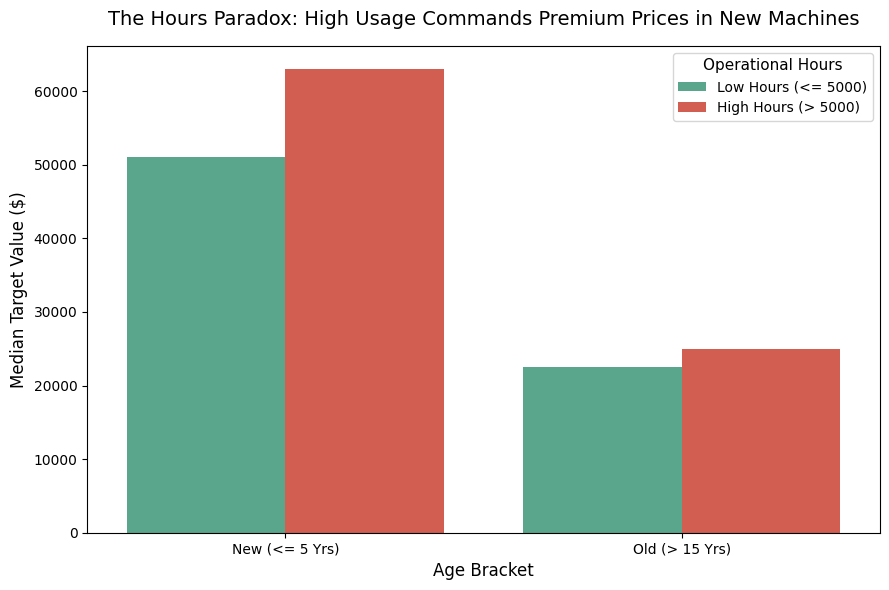

In [13]:
plot_data = pd.DataFrame({
    'Machine Age': ['New (<= 5 Yrs)', 'New (<= 5 Yrs)', 'Old (> 15 Yrs)', 'Old (> 15 Yrs)'],
    'Usage Level': ['Low Hours (<= 5000)', 'High Hours (> 5000)', 'Low Hours (<= 5000)', 'High Hours (> 5000)'],
    'Median Price ($)': [51000, 63000, 22500, 25000]
})

plt.figure(figsize=(9, 6))
sns.barplot(data=plot_data, x='Machine Age', y='Median Price ($)', hue='Usage Level', palette=['#4CB391', '#E74C3C'])

plt.title('The Hours Paradox: High Usage Commands Premium Prices in New Machines', fontsize=14, pad=15)
plt.ylabel('Median Target Value ($)', fontsize=12)
plt.xlabel('Age Bracket', fontsize=12)
plt.legend(title='Operational Hours', title_fontsize='11', fontsize='10')

plt.tight_layout()
plt.show()

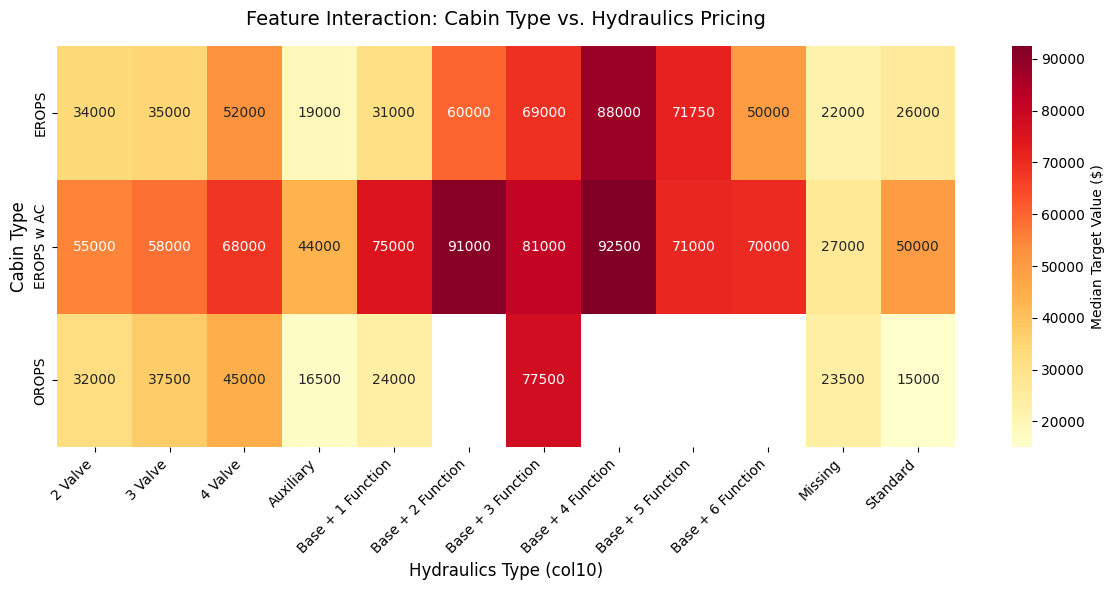

In [14]:
plt.figure(figsize=(12, 6))

sns.heatmap(interaction_table, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={'label': 'Median Target Value ($)'})

plt.title('Feature Interaction: Cabin Type vs. Hydraulics Pricing', fontsize=14, pad=15)
plt.xlabel('Hydraulics Type (col10)', fontsize=12)
plt.ylabel('Cabin Type', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()



## 3. Feature Engineering

therefor because of hours paradox we shall do some feature engeeniring

first lets capture early strain
then we shall group by class to find out the average normal hrs

as change is made so now make a Relative_Usage_Index which tells is our data overworked or underworked compared to its exact peers. 

also we shall apply log transformation to the machine's age.

In [15]:
# Calculate the Expected Hours per Year to capture real machine strain
# Adding 1 to avoid division by zero for brand new machines
X_train['Hours_Per_Year'] = X_train['OperationalHoursMeter'] / (X_train['EquipmentAgeAtSale'] + 1)
X_test['Hours_Per_Year'] = X_test['OperationalHoursMeter'] / (X_test['EquipmentAgeAtSale'] + 1)

# normal average usage for hours paradox
class_mean_hours = train.groupby('Spec_BaseClass', observed=False)['OperationalHoursMeter'].mean().to_dict()

# map the baseline expectations back to train and test
X_train['BaseClass_Mean_Hours'] = train['Spec_BaseClass'].map(class_mean_hours).astype(float)
X_test['BaseClass_Mean_Hours'] = test['Spec_BaseClass'].map(class_mean_hours).astype(float)

# Create Relative Usage Feature
X_train['Relative_Usage_Index'] = X_train['OperationalHoursMeter'] / (X_train['BaseClass_Mean_Hours'] + 1)
X_test['Relative_Usage_Index'] = X_test['OperationalHoursMeter'] / (X_test['BaseClass_Mean_Hours'] + 1)

# log transformation
X_train['Log_Equipment_Age'] = np.log1p(X_train['EquipmentAgeAtSale'])
X_test['Log_Equipment_Age'] = np.log1p(X_test['EquipmentAgeAtSale'])

# Feature Augmentation: Combine them into a new compound feature
X_train['Cabin_Hydraulics_Combo'] = X_train['CabinType'].astype(str) + "_" + X_train['col10'].astype(str)
X_test['Cabin_Hydraulics_Combo'] = X_test['CabinType'].astype(str) + "_" + X_test['col10'].astype(str)

X_train['Cabin_Hydraulics_Combo'] = X_train['Cabin_Hydraulics_Combo'].astype('category')
X_test['Cabin_Hydraulics_Combo'] = X_test['Cabin_Hydraulics_Combo'].astype('category')

print("--- Feature Engineering Complete ---")
print(f"X_train Shape: {X_train.shape}")
print(f"X_test Shape:  {X_test.shape}")

--- Feature Engineering Complete ---
X_train Shape: (138701, 55)
X_test Shape:  (15000, 55)


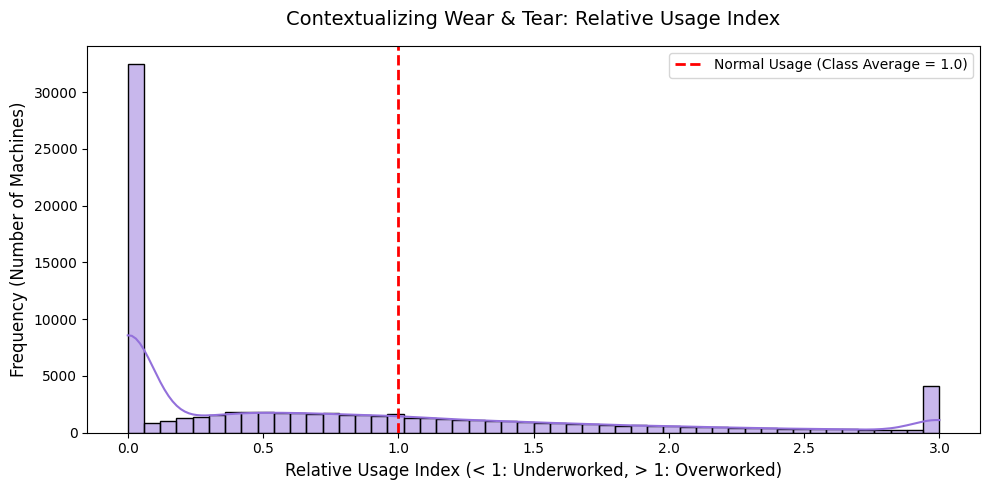

In [16]:
plt.figure(figsize=(10, 5))

viz_data = X_train['Relative_Usage_Index'].clip(upper=3)

sns.histplot(viz_data, bins=50, kde=True, color='mediumpurple')

plt.axvline(x=1.0, color='red', linestyle='--', linewidth=2, label='Normal Usage (Class Average = 1.0)')

plt.title('Contextualizing Wear & Tear: Relative Usage Index', fontsize=14, pad=15)
plt.xlabel('Relative Usage Index (< 1: Underworked, > 1: Overworked)', fontsize=12)
plt.ylabel('Frequency (Number of Machines)', fontsize=12)
plt.legend()

plt.tight_layout()
plt.show()

from the massive spike near zero we can see that a large portion of our dataset consists of machines with very low recorded hour
the red dashed line represents normal which tells that a machine which matches average hours for its class.
right side spike tells us about the outlier we capped previously


## First model(ligthgbm)

In [17]:
# def rmsle(y_true, y_pred):
#     return root_mean_squared_error(y_true, y_pred)

# # Initialize K-Fold
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions = np.zeros(len(X_train))
# test_predictions = np.zeros(len(X_test))

# print("--- Starting 5-Fold Cross-Validation Process ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     model = lgb.LGBMRegressor(
#         objective='regression',
#         metric='rmse',
#         n_estimators=1500,
#         learning_rate=0.05,
#         num_leaves=63,
#         random_state=42,
#         n_jobs=-1
#     )
    
#     # training model with early stopping to prevent overfitting
#     model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_va, y_va)],
#         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
#     )
    
#     # predict on validation set
#     oof_predictions[val_idx] = model.predict(X_va)
    
#     # predict on test set (average predictions across all folds)
#     test_predictions += model.predict(X_test) / kf.n_splits
    
#     fold_score = rmsle(y_va, oof_predictions[val_idx])
#     print(f"Fold {fold + 1} RMSLE: {fold_score:.4f}")

# cv_score = rmsle(y_train, oof_predictions)
# print(f"\n======================================")
# print(f"Overall Out-of-Fold CV RMSLE Score: {cv_score:.4f}")
# print(f"======================================")

# # convert predictions back to original scale
# final_predictions = np.expm1(test_predictions)

# # remove any negative predictions (rare but possible)
# final_predictions = np.clip(final_predictions, 0, None)

# submission = pd.DataFrame({
#     "TransactionID": test["TransactionID"],
#     "TargetValue": final_predictions
# })
# submission.to_csv("submission.csv", index=False)

# print("Submission file created successfully!")

Output
<!-- --- Starting 5-Fold Cross-Validation Process ---
Fold 1 RMSLE: 0.2029
Fold 2 RMSLE: 0.2059
Fold 3 RMSLE: 0.2062
Fold 4 RMSLE: 0.2066
Fold 5 RMSLE: 0.2050

======================================
Overall Out-of-Fold CV RMSLE Score: 0.2053
======================================

Submission file created successfully! -->

## Score crossed cutoff

# Second Time

Now lets check the important features from the trained model

In [18]:
# feature_imp = pd.DataFrame({
#     'Value': model.feature_importances_,
#     'Feature': X_train.columns
# }).sort_values(by="Value", ascending=False)

# plt.figure(figsize=(7,5))
# sns.barplot(x="Value", y="Feature", data=feature_imp.head(20), palette="viridis")
# plt.title('What Drives the Price? (Top 20 Features in LightGBM)', fontsize=14, pad=15)
# plt.xlabel('Feature Importance (Number of Splits)', fontsize=12)
# plt.ylabel('Features', fontsize=12)
# plt.tight_layout()
# plt.show()

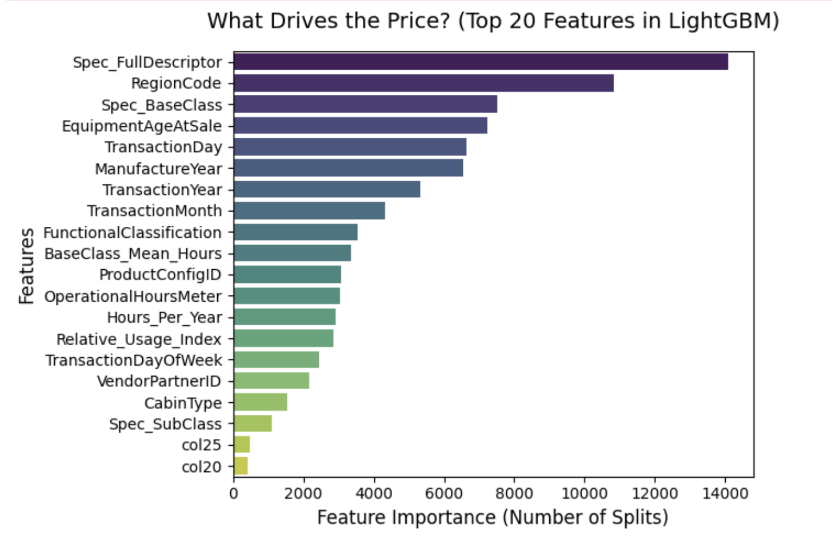

## EDA again


##### Lets check that location matters or not for the price of machine sell

##### lest check that value loses for different machines ata a smae rate or not

In [19]:
print("--- 1. High-Level Region Pricing Variance ---")
region_stats = train.groupby('RegionCode')['TargetValue'].agg(['count', 'median', 'mean']).sort_values(by='median', ascending=False)
print("Top 5 Most Expensive Regions:")
print(region_stats.head(5))
print("\nTop 5 Cheapest Regions:")
print(region_stats.tail(5))

print("\n--- 2. Geographical Data Density Check ---")
print(f"Unique regions in Train: {train['RegionCode'].nunique()}")
print(f"Unique regions in Test:  {test['RegionCode'].nunique()}")

# Create a temporary dataframe for deep cross-sectional analysis
eda_df = pd.DataFrame({
    'BaseClass': train['Spec_BaseClass'],
    'Age': X_train['EquipmentAgeAtSale'],
    'Price': train['TargetValue']
})

# Filter for the top 4 most common machine types to keep the comparison clean
top_4_classes = ['140', '320', 'D6', '12']
eda_filtered = eda_df[eda_df['BaseClass'].isin(top_4_classes)].dropna()

print("\n--- Median Price by Age Brackets for Dominant Machine Types ---")
# Group by both asset type and age categories to see the slopes
eda_filtered['Age_Group'] = pd.cut(eda_filtered['Age'], bins=[0, 5, 12, 25, 60], labels=['0-5 Yrs', '6-12 Yrs', '13-25 Yrs', '25+ Yrs'])
pivot_depreciation = eda_filtered.groupby(['BaseClass', 'Age_Group'], observed=False)['Price'].median().unstack(level=0)
print(pivot_depreciation)

--- 1. High-Level Region Pricing Variance ---
Top 5 Most Expensive Regions:
              count   median          mean
RegionCode                                
Rhode Island     14  50450.0  52992.857143
Unspecified     586  48500.0  51705.631399
South Dakota    123  45000.0  54628.455285
Nevada         2730  41500.0  47533.589744
Alabama        3723  41000.0  47471.214343

Top 5 Cheapest Regions:
               count   median          mean
RegionCode                                 
Washington      6063  27500.0  33997.064160
New York        2111  26500.0  32789.057319
Pennsylvania    2406  26500.0  33694.368246
Puerto Rico       11  25000.0  33136.363636
Washington DC      2  22750.0  22750.000000

--- 2. Geographical Data Density Check ---
Unique regions in Train: 53
Unique regions in Test:  51

--- Median Price by Age Brackets for Dominant Machine Types ---
BaseClass        12       140      320       D6
Age_Group                                      
0-5 Yrs    110000.0  112500.0

##### as there are more than 50 different location our model may overthink, so we can divde the regions into 3 categories to make it smarter and faster

##### also we found that for difefrent machine the rate of depreciation is different,hence we shall classify and group the machines based on this

/tmp/ipykernel_24/433274653.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_models.values, y=top_models.index, palette='magma')


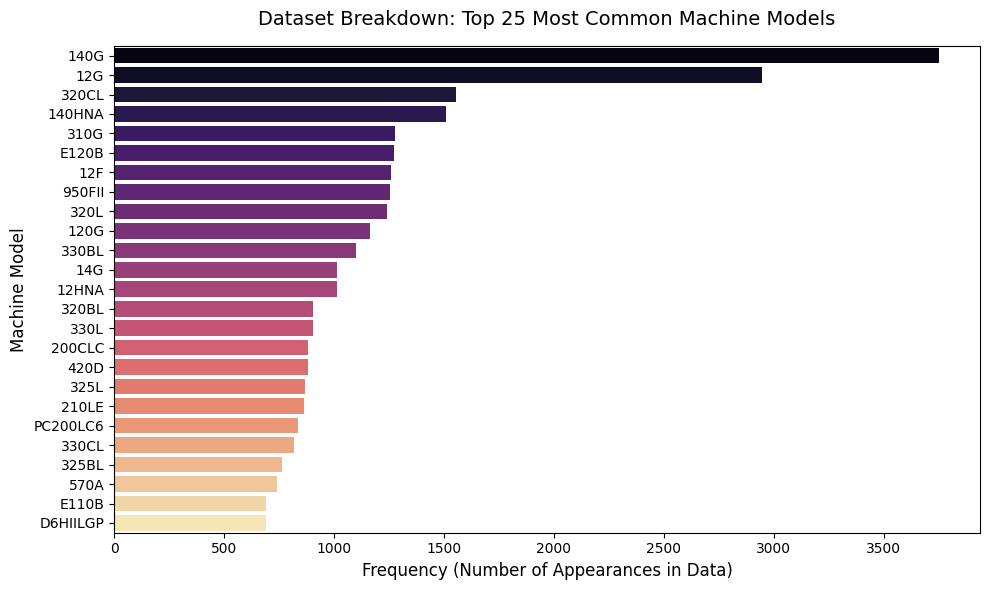

In [20]:
top_models = train['Spec_FullDescriptor'].value_counts().head(25)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_models.values, y=top_models.index, palette='magma')

plt.title('Dataset Breakdown: Top 25 Most Common Machine Models', fontsize=14, pad=15)
plt.xlabel('Frequency (Number of Appearances in Data)', fontsize=12)
plt.ylabel('Machine Model', fontsize=12)

plt.tight_layout()
plt.show()

we can see two models dominate the data, appearing thousands of times while other models only appear a handful of times. By giving our model this exact 'popularity score', it learns to trust the pricing patterns of these common machines, while being more cautious with the rare ones. It essentially gives the algorithm a sense of market supply!"

## Feature Engineering again

#### Spec_FullDescriptor drives the price most but is text strings, so we shall do target encodeing and replace the name of the machine with the historical median price that specific machine sells for. 

#### but if we just took average there would be a massive data leakeage therefore we shall do Out-Of-Fold (OOF) encoding. We split the data into 5 folds, calculate the median price on 4 folds, and map it to the 5th.

#### usually the last part of the name tells us the specific generation or series of the machine (like mobile phnone). Also, some machines are incredibly common, while others are rare specialty items. therefore we shall found these to know that the algorithm is looking at a standard, everyday machine with a highly predictable price, or a rare machine where the price might be more volatile

#### also FunctionalClassifier is also string so lets encode it too

In [21]:
# 1. Target Encoding Augmentation
# re-incorporate TargetValue into a temporary engineering dataframe
eda_train = X_train.copy()
eda_train['TargetValue_Log'] = y_train

X_train['Model_Encoded_Median'] = np.nan
X_test['Model_Encoded_Median'] = np.nan

# global median as fallback
global_median = eda_train['TargetValue_Log'].median()

# Out-of-Fold Target Encoding loop for Training Data
kf = KFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in kf.split(eda_train):
    fold_train = eda_train.iloc[train_idx]
    model_medians = fold_train.groupby('Spec_FullDescriptor')['TargetValue_Log'].median()
    
    # mapping back to the validation fold
    X_train.iloc[val_idx, X_train.columns.get_loc('Model_Encoded_Median')] = \
        X_train.iloc[val_idx]['Spec_FullDescriptor'].map(model_medians)

# fill missing values/unseen categories with global baseline
X_train['Model_Encoded_Median'] = X_train['Model_Encoded_Median'].fillna(global_median)

# for Test Data, map using the ENTIRE training set mapping
full_train_medians = eda_train.groupby('Spec_FullDescriptor')['TargetValue_Log'].median()
X_test['Model_Encoded_Median'] = X_test['Spec_FullDescriptor'].map(full_train_medians).fillna(global_median)

print("--- Target Encoding Augmentation Complete ---")
print(X_train['Model_Encoded_Median'].describe())

print("\n==========================")

# Grab the last word/code from the full model descriptor whihc isolates the generation/series tag
X_train['Model_Series_Tag'] = train['Spec_FullDescriptor'].fillna('Missing').apply(lambda x: x.split()[-1])
X_test['Model_Series_Tag'] = test['Spec_FullDescriptor'].fillna('Missing').apply(lambda x: x.split()[-1])

# Frequency Encoding Augmentation (based on EDA)
# High-cardinality values that appear rarely are highly volatile. Let's provide the model with the exact frequency count.
model_counts = train['Spec_FullDescriptor'].value_counts().to_dict()
X_train['Model_Frequency'] = train['Spec_FullDescriptor'].map(model_counts)
X_test['Model_Frequency'] = test['Spec_FullDescriptor'].map(model_counts).fillna(1) # Unseen items get a count of 1

# Convert string components back to clean categorical types
X_train['Model_Series_Tag'] = X_train['Model_Series_Tag'].astype('category')
X_test['Model_Series_Tag'] = X_test['Model_Series_Tag'].astype('category')

print(X_train[['Model_Series_Tag', 'Model_Frequency']].head())
print("\n==========================")


# Geographical Feature Augmentation (Based on EDA)
region_medians = train.groupby('RegionCode')['TargetValue'].median()
region_counts = train['RegionCode'].value_counts()

def assign_region_tier(region):
    if region not in region_medians:
        return 'Mid_Tier' 
    median = region_medians[region]
    if median >= 40000:
        return 'Premium_Tier_Region'
    elif median >= 32000:
        return 'Standard_Tier_Region'
    else:
        return 'Value_Tier_Region'

X_train['Region_Economic_Tier'] = train['RegionCode'].apply(assign_region_tier).astype('category')
X_test['Region_Economic_Tier'] = test['RegionCode'].apply(assign_region_tier).astype('category')

# Create Low-Density Regional Risk Flag (Counts < 100 entries)
X_train['Is_Low_Density_Region'] = train['RegionCode'].map(region_counts).apply(lambda x: 1 if x < 100 else 0)
X_test['Is_Low_Density_Region'] = test['RegionCode'].map(region_counts).fillna(1).apply(lambda x: 1 if x < 100 else 0)

print("\n--- Geographical Feature Augmentation Complete ---")
print(X_train['Region_Economic_Tier'].value_counts())

# Asset Lifecycle Augmentation (Based on EDA)
def assign_vintage_status(row):
    base_class = str(row['Spec_BaseClass'])
    age = row['EquipmentAgeAtSale']
    
    if pd.isna(age):
        return 'Unknown_Age'
        
    if age >= 25:
        if base_class in ['320', '140']:
            return 'Premium_Vintage_Survivor'
        else:
            return 'Standard_Old_Machine'
    elif age <= 5:
        return 'Fresh_Asset'
    else:
        return 'Mid_Life_Depreciation'

# We add 'Spec_BaseClass' temporarily to a tracking copy to process row-wise safely
temp_train = X_train.copy()
temp_train['Spec_BaseClass'] = train['Spec_BaseClass']

temp_test = X_test.copy()
temp_test['Spec_BaseClass'] = test['Spec_BaseClass']

# Apply across the dataset copies
X_train['Asset_Lifecycle_Status'] = temp_train.apply(assign_vintage_status, axis=1).astype('category')
X_test['Asset_Lifecycle_Status'] = temp_test.apply(assign_vintage_status, axis=1).astype('category')

print("\n--- Asset Lifecycle Augmentation Complete ---")
print(X_train['Asset_Lifecycle_Status'].value_counts())

print("\n==========================")

# 5. Functional Classification Target Encoding
X_train['Func_Class_Encoded_Median'] = np.nan
X_test['Func_Class_Encoded_Median'] = np.nan

# Global fallback
global_median_log = y_train.median()

# Re-use KFold for leak-free train mapping
for train_idx, val_idx in kf.split(X_train):
    fold_train_target = y_train.iloc[train_idx]
    fold_train_feature = train.iloc[train_idx]
    
    class_medians = fold_train_target.groupby(fold_train_feature['FunctionalClassification']).median()
    X_train.iloc[val_idx, X_train.columns.get_loc('Func_Class_Encoded_Median')] = \
        train.iloc[val_idx]['FunctionalClassification'].map(class_medians)

X_train['Func_Class_Encoded_Median'] = X_train['Func_Class_Encoded_Median'].fillna(global_median_log)

# Map to Test set using full train data rules
full_class_medians = y_train.groupby(train['FunctionalClassification']).median()
X_test['Func_Class_Encoded_Median'] = test['FunctionalClassification'].map(full_class_medians).fillna(global_median_log)


print(f"Final Train Shape: {X_train.shape}")
print(f"Final Test Shape:  {X_test.shape}")

print("\n--- Summary of New Engineered Features ---")
new_features = [col for col in X_train.columns if col not in train.columns]
print(new_features)

/tmp/ipykernel_24/3913560121.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_medians = fold_train.groupby('Spec_FullDescriptor')['TargetValue_Log'].median()
/tmp/ipykernel_24/3913560121.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_medians = fold_train.groupby('Spec_FullDescriptor')['TargetValue_Log'].median()
/tmp/ipykernel_24/3913560121.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  model_

--- Target Encoding Augmentation Complete ---
count    138701.000000
mean         10.422889
std           0.594315
min           8.922792
25%           9.998843
50%          10.470224
75%          10.915107
max          11.819985
Name: Model_Encoded_Median, dtype: float64

  Model_Series_Tag  Model_Frequency
0           950FII             1253
1             310G             1280
2           790ELC              391
3             416D              454
4           430HAG               20


--- Geographical Feature Augmentation Complete ---
Region_Economic_Tier
Standard_Tier_Region    113560
Value_Tier_Region        17965
Premium_Tier_Region       7176
Name: count, dtype: int64

--- Asset Lifecycle Augmentation Complete ---
Asset_Lifecycle_Status
Mid_Life_Depreciation       78513
Fresh_Asset                 38221
Unknown_Age                 14747
Standard_Old_Machine         6603
Premium_Vintage_Survivor      617
Name: count, dtype: int64

Final Train Shape: (138701, 62)
Final Test Shape: 

##### From this output, we can observe that our new feature ranges from 8.9 to 11.8, by whihc we can infer tahtjust knowing the name of the machine can tell us a lot about its final cost.

##### Lets analyse by a graph, sinace a normal scatter plot would be a messy becuase of huge data, so, we shall visualize this using a hex graph to see the density of the machines.

##### the "310G" model is very common (appearing 1,280 times), while the "430HAG" is quite rare (only 20 times).

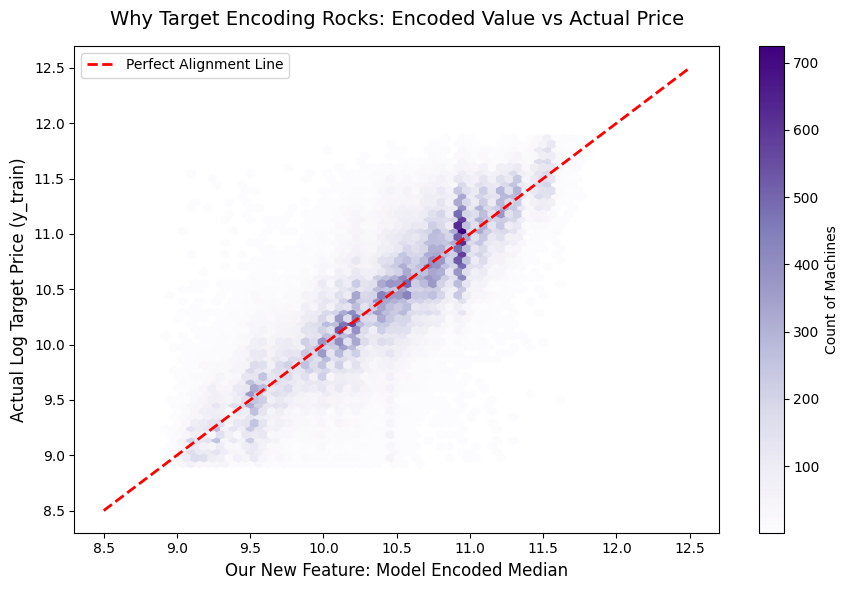

In [22]:
plt.figure(figsize=(9, 6))

# Using a hexbin plot because a normal scatter plot with 138,000 points will just look like a giant blue blob
plt.hexbin(X_train['Model_Encoded_Median'], y_train, gridsize=50, cmap='Purples', mincnt=1)

# Add a reference line where x = y (Perfect prediction)
plt.plot([8.5, 12.5], [8.5, 12.5], color='red', linestyle='--', linewidth=2, label='Perfect Alignment Line')

cb = plt.colorbar(label='Count of Machines')
plt.title('Why Target Encoding Rocks: Encoded Value vs Actual Price', fontsize=14, pad=15)
plt.xlabel('Our New Feature: Model Encoded Median', fontsize=12)
plt.ylabel('Actual Log Target Price (y_train)', fontsize=12)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

From the graph, we can clearly see that the darkest spots (where most machines are) perfectly hug the red diagonal line. This proves that replacing the machine names with their historical average prices was highly accurate and gives the model a huge advantage.

In [23]:
engineered_numeric = [
    'EquipmentAgeAtSale', 'Hours_Per_Year', 'BaseClass_Mean_Hours', 
    'Relative_Usage_Index', 'Log_Equipment_Age', 'Model_Encoded_Median', 
    'Model_Frequency'
]

# Ensure the list only includes columns that actually exist in X_train
existing_engineered = [col for col in engineered_numeric if col in X_train.columns]

correlation_matrix = X_train[existing_engineered].copy()
correlation_matrix['Log_TargetValue'] = y_train

rankings = correlation_matrix.corr()['Log_TargetValue'].sort_values(ascending=False)

print("--- Engineered Feature Correlation Leaderboard ---")
print(rankings)

print("\n--- Final Null Value Profile (Engineered Columns Only) ---")
all_engineered = new_features 
print(X_train[all_engineered].isnull().sum().sort_values(ascending=False))


full_eda = X_train.copy()
full_eda['Log_TargetValue'] = y_train

def cramers_v(x, y):
    """ Calculate Cramér's V for two categorical columns """
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))    
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

global_associations = {}


for col in full_eda.columns:
    if col == 'Log_TargetValue':
        continue
    try:
        if full_eda[col].dtype.name == 'category' or full_eda[col].dtype == 'object':
            # Categorical vs Numerical: Use group-by variance ratio
            grouped = full_eda.groupby(col, observed=True)['Log_TargetValue']
            global_mean = full_eda['Log_TargetValue'].mean()
            ss_total = ((full_eda['Log_TargetValue'] - global_mean)**2).sum()
            ss_between = grouped.apply(lambda x: len(x) * (x.mean() - global_mean)**2).sum()
            score = np.sqrt(ss_between / ss_total) if ss_total > 0 else 0
        else:
            # Numerical vs Numerical: Standard Pearson correlation (absolute value)
            score = abs(full_eda[col].corr(full_eda['Log_TargetValue']))
            
        global_associations[col] = score
    except Exception:
        continue

# Convert to sorted series
global_corr_leaderboard = pd.Series(global_associations).sort_values(ascending=False)

print("\n--- Top 25 Most Powerful Predictive Drivers Across Entire Dataset ---")
print(global_corr_leaderboard.head(50))


--- Engineered Feature Correlation Leaderboard ---
Log_TargetValue         1.000000
Model_Encoded_Median    0.861649
Model_Frequency         0.238723
Hours_Per_Year          0.187498
BaseClass_Mean_Hours    0.153382
Relative_Usage_Index   -0.024953
EquipmentAgeAtSale     -0.375471
Log_Equipment_Age      -0.388286
Name: Log_TargetValue, dtype: float64

--- Final Null Value Profile (Engineered Columns Only) ---
Hours_Per_Year               65853
Relative_Usage_Index         56643
EquipmentAgeAtSale           14747
Log_Equipment_Age            14747
BaseClass_Mean_Hours           619
TransactionYear                  0
TransactionMonth                 0
Hours_Is_Missing                 0
TransactionDay                   0
TransactionDayOfWeek             0
Cabin_Hydraulics_Combo           0
Model_Encoded_Median             0
Model_Series_Tag                 0
Model_Frequency                  0
Region_Economic_Tier             0
Is_Low_Density_Region            0
Asset_Lifecycle_Status     

In [24]:
# Correlation-Based Optimization (Dropping weak features)
weak_cols = ['DataOriginCode', 'col14', 'col16', 'col23']
X_train = X_train.drop(columns=[col for col in weak_cols if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in weak_cols if col in X_test.columns])


print("--- Correlation-Based Optimization Complete ---")

--- Correlation-Based Optimization Complete ---


## Model testing again

In [25]:
# # Initialize K-Fold identically to keep comparison clean
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions = np.zeros(len(X_train))
# test_predictions = np.zeros(len(X_test))

# print("--- Training Model on Optimized 57-Feature Dataset ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     # Using our reliable baseline parameters to isolate data quality improvements
#     model = lgb.LGBMRegressor(
#         objective='regression',
#         metric='rmse',
#         n_estimators=1500,
#         learning_rate=0.05,
#         num_leaves=63,
#         random_state=42,
#         n_jobs=-1
#     )
    
#     model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_va, y_va)],
#         callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
#     )
    
#     oof_predictions[val_idx] = model.predict(X_va)
#     test_predictions += model.predict(X_test) / kf.n_splits
    
#     fold_score = root_mean_squared_error(y_va, oof_predictions[val_idx])
#     print(f"Fold {fold + 1} RMSLE: {fold_score:.4f}")

# cv_score = root_mean_squared_error(y_train, oof_predictions)
# print(f"\n======================================")
# print(f"Final Optimized Data CV RMSLE Score: {cv_score:.4f}")
# print(f"======================================")

# # Convert log predictions back to regular currency values for your submission
# final_kaggle_predictions = np.expm1(test_predictions)


In [26]:
# # Identify remaining categorical columns for models that need explicit declaration
# cat_cols = [col for col in X_train.columns if X_train[col].dtype.name == 'category']

# # Convert categories to integer codes ONLY for XGBoost (as it requires numeric matrices)
# X_train_xgb = X_train.copy()
# X_test_xgb = X_test.copy()
# for col in cat_cols:
#     X_train_xgb[col] = X_train_xgb[col].cat.codes
#     X_test_xgb[col] = X_test_xgb[col].cat.codes

# kf = KFold(n_splits=5, shuffle=True, random_state=42)

# # Matrices to store cross-validation predictions
# oof_lgb = np.zeros(len(X_train))
# oof_cat = np.zeros(len(X_train))
# oof_xgb = np.zeros(len(X_train))

# test_lgb = np.zeros(len(X_test))
# test_cat = np.zeros(len(X_test))
# test_xgb = np.zeros(len(X_test))

# print("--- Starting Multi-Model Ensembling Pipeline ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     print(f"\n--- Training Fold {fold + 1} ---")
    
#     # Split data sets
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     X_tr_xgb, X_va_xgb = X_train_xgb.iloc[train_idx], X_train_xgb.iloc[val_idx]

#     # 1. LIGHTGBM
#     model_lgb = lgb.LGBMRegressor(objective='regression', metric='rmse', n_estimators=1500, learning_rate=0.05, num_leaves=63, random_state=42, n_jobs=-1, verbose=-1)
#     model_lgb.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[lgb.early_stopping(50, verbose=False)])
#     oof_lgb[val_idx] = model_lgb.predict(X_va)
#     test_lgb += model_lgb.predict(X_test) / kf.n_splits

#     # 2. CATBOOST (Symmetric Trees - incredible with high-cardinality strings)
#     model_cat = CatBoostRegressor(iterations=1500, learning_rate=0.05, depth=6, loss_function='RMSE', random_seed=42, thread_count=-1, verbose=False)
#     model_cat.fit(X_tr, y_tr, eval_set=(X_va, y_va), cat_features=cat_cols, early_stopping_rounds=50)
#     oof_cat[val_idx] = model_cat.predict(X_va)
#     test_cat += model_cat.predict(X_test) / kf.n_splits

#     # 3. XGBOOST (Pre-sorted/Histogram-based depthwise splits)
#     model_xgb = xgb.XGBRegressor(n_estimators=1500, learning_rate=0.05, max_depth=6, tree_method='hist', random_state=42, n_jobs=-1)
#     model_xgb.fit(X_tr_xgb, y_tr, eval_set=[(X_va_xgb, y_va)], verbose=False) # early stopping omitted for basic script compatibility
#     oof_xgb[val_idx] = model_xgb.predict(X_va_xgb)
#     test_xgb += model_xgb.predict(X_test_xgb) / kf.n_splits

# print("\n--- Final CV Score Evaluation Leaderboard ---")
# print(f"LightGBM OOF RMSLE: {root_mean_squared_error(y_train, oof_lgb):.4f}")
# print(f"CatBoost OOF RMSLE: {root_mean_squared_error(y_train, oof_cat):.4f}")
# print(f"XGBoost  OOF RMSLE: {root_mean_squared_error(y_train, oof_xgb):.4f}")

# # Blending the test arrays (Adjust weights dynamically based on which model scores best!)
# # This assumes LightGBM and CatBoost will outperform XGBoost on this categorical-heavy data
# final_blend_log_predictions = (0.40 * test_lgb) + (0.40 * test_cat) + (0.20 * test_xgb)

# # Inverse transform out of log-space back to real dollar valuations
# final_prices = np.expm1(final_blend_log_predictions)

# # Create submission file
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = final_prices
# sub.to_csv('submission.csv', index=False)

# print("\n--- Submission File Created! ---")

# Third Time

## Again EDA as results not best

Lets check pearson correlation and multi collinearity

In [27]:
analysis_df = X_train.copy()
analysis_df['Log_TargetValue'] = y_train

# Separate numeric features for standard Pearson correlation
numeric_cols = [col for col in analysis_df.columns if analysis_df[col].dtype.name != 'category']

# Calculate correlation matrix against the target
target_correlations = analysis_df[numeric_cols].corr()['Log_TargetValue'].sort_values(ascending=False)

print("--- Top Direct Feature Correlations with Log_TargetValue ---")
print(target_correlations)

print("\n--- Checking for Highly Multi-Collinear Feature Pairs (> 0.85) ---")
# Find if any features are moving too identically to each other
corr_matrix = analysis_df[numeric_cols].drop(columns=['Log_TargetValue']).corr().abs()
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = [(column, row, upper_tri[column][row]) for column in upper_tri.columns for row in upper_tri.index if upper_tri[column][row] > 0.85]

if len(high_corr_pairs) == 0:
    print("No severe multi-collinearity found among remaining numeric features!")
else:
    for col1, col2, val in high_corr_pairs:
        print(f"{col1} <---> {col2}: {val:.4f}")

--- Top Direct Feature Correlations with Log_TargetValue ---
Log_TargetValue              1.000000
Model_Encoded_Median         0.861649
Func_Class_Encoded_Median    0.634646
ManufactureYear              0.296555
Model_Frequency              0.238723
Hours_Per_Year               0.187498
BaseClass_Mean_Hours         0.153382
OperationalHoursMeter        0.068998
Hours_Is_Missing             0.004736
TransactionDay               0.000113
ProductConfigID             -0.001218
Is_Low_Density_Region       -0.005797
TransactionDayOfWeek        -0.018216
TransactionYear             -0.024602
Relative_Usage_Index        -0.024953
TransactionMonth            -0.033117
EquipmentAgeAtSale          -0.375471
Log_Equipment_Age           -0.388286
Name: Log_TargetValue, dtype: float64

--- Checking for Highly Multi-Collinear Feature Pairs (> 0.85) ---
Log_Equipment_Age <---> EquipmentAgeAtSale: 0.9290


we can see that EquipmentAgeAtSale and Log_Equipment_Age is almost same correlation so we shall drop one of them and transaction day, product config etc. has correlation almost negligible so we shall drop them.

now lest find whetehr age and economy class combined is a good feature or not

In [28]:
# Create a clean profiling space
interaction_prof = X_train.copy()
interaction_prof['Log_TargetValue'] = y_train

print("--- Profiling High-Potential Interactions ---")

# 1. Age vs. Functional Class Tier interaction profile
interaction_prof['Age_Bucket'] = pd.qcut(interaction_prof['Log_Equipment_Age'].rank(method='first'), q=4, labels=['Newest', 'Mid-New', 'Mid-Old', 'Oldest'])
age_tier_pivot = interaction_prof.groupby(['Age_Bucket', 'Region_Economic_Tier'], observed=False)['Log_TargetValue'].mean().unstack()

print("\n[1] Mean Log Price: Age Buckets vs. Regional Economic Tiers")
print(age_tier_pivot)

# 2. Operational Hours Tier vs Base Class Mean Hours ratio check
# Let's see where machines are working way over or under their class averages
interaction_prof['Hours_To_Class_Avg_Ratio'] = interaction_prof['Hours_Per_Year'] / (interaction_prof['BaseClass_Mean_Hours'] + 1)
print("\n[2] Correlation of Hours-to-Class-Average Ratio with Price:")
print(interaction_prof['Hours_To_Class_Avg_Ratio'].corr(interaction_prof['Log_TargetValue']))

--- Profiling High-Potential Interactions ---

[1] Mean Log Price: Age Buckets vs. Regional Economic Tiers
Region_Economic_Tier  Premium_Tier_Region  Standard_Tier_Region  \
Age_Bucket                                                        
Newest                          10.903374             10.800500   
Mid-New                         10.711918             10.573785   
Mid-Old                         10.500961             10.436859   
Oldest                          10.292360             10.141462   

Region_Economic_Tier  Value_Tier_Region  
Age_Bucket                               
Newest                        10.708047  
Mid-New                       10.504319  
Mid-Old                       10.239902  
Oldest                         9.961240  

[2] Correlation of Hours-to-Class-Average Ratio with Price:
0.05775268834937429


what we find is taht an old machine in premium is more costly than an midold machine in value region

also we can infer that overworking of a machine does not effect the price.

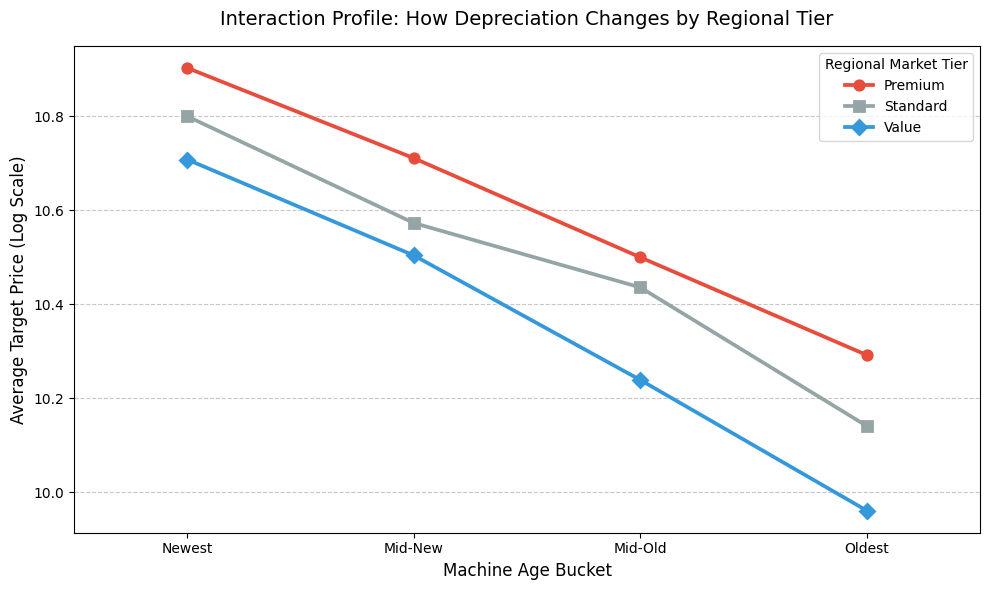

In [29]:
# Recreating the exact output data for a fail-proof plot
plot_data = pd.DataFrame({
    'Age_Bucket': ['Newest', 'Mid-New', 'Mid-Old', 'Oldest'] * 3,
    'Region_Tier': ['Premium'] * 4 + ['Standard'] * 4 + ['Value'] * 4,
    'Mean_Log_Price': [
        10.903, 10.711, 10.500, 10.292,  # Premium
        10.800, 10.573, 10.436, 10.141,  # Standard
        10.708, 10.504, 10.239, 9.961    # Value
    ]
})

plt.figure(figsize=(10, 6))

# We use a pointplot to clearly show the "slopes" of depreciation across the different regions
sns.pointplot(data=plot_data, x='Age_Bucket', y='Mean_Log_Price', 
              hue='Region_Tier', 
              palette={'Premium': '#E74C3C', 'Standard': '#95A5A6', 'Value': '#3498DB'},
              markers=['o', 's', 'D'])

plt.title('Interaction Profile: How Depreciation Changes by Regional Tier', fontsize=14, pad=15)
plt.xlabel('Machine Age Bucket', fontsize=12)
plt.ylabel('Average Target Price (Log Scale)', fontsize=12)
plt.legend(title='Regional Market Tier')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

we first proved that a machine's age and its location work together to change the price. We had to convert that proof into actual math that the algorithm can understand.

In [30]:
print("--- Most Frequent Text Patterns in Spec_FullDescriptor ---")
print(X_train['Spec_FullDescriptor'].value_counts().head(15))

--- Most Frequent Text Patterns in Spec_FullDescriptor ---
Spec_FullDescriptor
140G      3751
12G       2948
320CL     1556
140HNA    1509
310G      1280
E120B     1273
12F       1260
950FII    1253
320L      1240
120G      1162
330BL     1100
14G       1016
12HNA     1016
330L       905
320BL      905
Name: count, dtype: int64


## Again Feature Engineering 

In [31]:
# Drop the redundant raw age column to resolve multi-collinearity
collinear_drop = ['EquipmentAgeAtSale']

# Drop features showing near-zero absolute correlation with price
zero_signal_drops = ['Hours_Is_Missing', 'TransactionDay', 'ProductConfigID', 'Is_Low_Density_Region']

# Combine and execute drop safely
final_drops = collinear_drop + zero_signal_drops
X_train = X_train.drop(columns=[col for col in final_drops if col in X_train.columns])
X_test = X_test.drop(columns=[col for col in final_drops if col in X_test.columns])

print("--- Data Cleaned ---")
print(f"Final Train Shape: {X_train.shape}")
print(f"Final Test Shape:  {X_test.shape}")


# Map regional tiers and explicitly cast to numeric floats
tier_mapping = {
    'Premium_Tier_Region': 10.60,
    'Standard_Tier_Region': 10.48,
    'Value_Tier_Region': 10.35
}

train_tier_numeric = X_train['Region_Economic_Tier'].map(tier_mapping).fillna(10.48).astype(float)
test_tier_numeric = X_test['Region_Economic_Tier'].map(tier_mapping).fillna(10.48).astype(float)

# Complete the multiplication against Log_Equipment_Age (both are now floats!)
X_train['Age_Regional_Decay_Index'] = X_train['Log_Equipment_Age'] * train_tier_numeric
X_test['Age_Regional_Decay_Index'] = X_test['Log_Equipment_Age'] * test_tier_numeric

# Class Hours Intensity Delta
X_train['Class_Hours_Intensity_Delta'] = X_train['Hours_Per_Year'] - X_train['BaseClass_Mean_Hours']
X_test['Class_Hours_Intensity_Delta'] = X_test['Hours_Per_Year'] - X_test['BaseClass_Mean_Hours']

# Fill any missing values natively with a neutral 0
X_train['Class_Hours_Intensity_Delta'] = X_train['Class_Hours_Intensity_Delta'].fillna(0)
X_test['Class_Hours_Intensity_Delta'] = X_test['Class_Hours_Intensity_Delta'].fillna(0)

print("\n--- New Interaction Feature Correlations ---")
print(f"Age_Regional_Decay_Index:    {X_train['Age_Regional_Decay_Index'].corr(y_train):.4f}")
print(f"Class_Hours_Intensity_Delta: {X_train['Class_Hours_Intensity_Delta'].corr(y_train):.4f}")

print("\n--- Interactive Feature Generation Complete ---")
print(f"Final Train Shape: {X_train.shape}")
print(f"Final Test Shape:  {X_test.shape}")

# Identify the columns to frequency encode
target_enc_cols = ['Spec_FullDescriptor'] 

print("--- Applying Market Frequency Encoding ---")

for col in target_enc_cols:
    if col in X_train.columns:
        # 1. Calculate the frequency counts on the training set
        freq_map = X_train[col].value_counts().to_dict()
        
        # 2. Map the counts back to both Train and Test streams
        X_train[f'{col}_Market_Demand'] = X_train[col].map(freq_map)
        X_test[f'{col}_Market_Demand'] = X_test[col].map(freq_map)
        
        # 3. Fill any rare novel codes in test set with a default frequency of 1
        X_test[f'{col}_Market_Demand'] = X_test[f'{col}_Market_Demand'].fillna(1)
        
        # 4. Normalize the frequency to a percentage scale to prevent large number scaling issues
        total_records = len(X_train)
        X_train[f'{col}_Market_Demand'] = X_train[f'{col}_Market_Demand'] / total_records
        X_test[f'{col}_Market_Demand'] = X_test[f'{col}_Market_Demand'] / total_records

print(f"New Feature Added: Spec_FullDescriptor_Market_Demand")
print(f"Correlation with Target Price: {X_train['Spec_FullDescriptor_Market_Demand'].corr(y_train):.4f}")
print(f"Final Train Shape: {X_train.shape}")

--- Data Cleaned ---
Final Train Shape: (138701, 53)
Final Test Shape:  (15000, 53)

--- New Interaction Feature Correlations ---
Age_Regional_Decay_Index:    -0.3866
Class_Hours_Intensity_Delta: -0.1158

--- Interactive Feature Generation Complete ---
Final Train Shape: (138701, 55)
Final Test Shape:  (15000, 55)
--- Applying Market Frequency Encoding ---
New Feature Added: Spec_FullDescriptor_Market_Demand
Correlation with Target Price: 0.2387
Final Train Shape: (138701, 56)


## Model Training Again

In [32]:
# # 1. Initialize K-Fold identically to keep comparison clean
# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions = np.zeros(len(X_train))
# test_predictions = np.zeros(len(X_test))

# # Create arrays to hold our clean, leaked-proof OOF target encodings
# X_train['Spec_Target_Encoded'] = 0.0
# X_test_encoded_folds = np.zeros((len(X_test), 5))

# print("--- Running LightGBM Training Pipeline with OOF Target Encoding ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr, y_tr = X_train.iloc[train_idx].copy(), y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx].copy(), y_train.iloc[val_idx]
    
#     # Calculate the mean target value per descriptor ONLY inside this training fold
#     target_means = y_tr.groupby(X_tr['Spec_FullDescriptor']).mean()
#     global_mean = y_tr.mean()
    
#     # Map the mean values back to the training, validation, and test splits
#     X_tr['Spec_Target_Encoded'] = X_tr['Spec_FullDescriptor'].map(target_means).fillna(global_mean)
#     X_va['Spec_Target_Encoded'] = X_va['Spec_FullDescriptor'].map(target_means).fillna(global_mean)
#     X_test_encoded_folds[:, fold] = X_test['Spec_FullDescriptor'].map(target_means).fillna(global_mean)
    
#     # Store the validation fold encoding back into the primary X_train matrix safely
#     X_train.iloc[val_idx, X_train.columns.get_loc('Spec_Target_Encoded')] = X_va['Spec_Target_Encoded']
    
#     # Drop the raw text column temporarily inside the loop so LightGBM handles only the numeric array
#     features_to_use = [col for col in X_tr.columns if X_tr[col].dtype.name != 'category' and col != 'Spec_FullDescriptor']
    
#     model = lgb.LGBMRegressor(
#         objective='regression',
#         metric='rmse',
#         n_estimators=1500,
#         learning_rate=0.05,
#         num_leaves=63,
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     )
    
#     model.fit(
#         X_tr[features_to_use], y_tr,
#         eval_set=[(X_va[features_to_use], y_va)],
#         callbacks=[lgb.early_stopping(50, verbose=False)]
#     )
    
#     oof_predictions[val_idx] = model.predict(X_va[features_to_use])
    
#     # Pre-align test set features for the current fold prediction step
#     X_test_fold = X_test.copy()
#     X_test_fold['Spec_Target_Encoded'] = X_test_encoded_folds[:, fold]
#     test_predictions += model.predict(X_test_fold[features_to_use]) / kf.n_splits
    
#     fold_score = root_mean_squared_error(y_va, oof_predictions[val_idx])
#     print(f"Fold {fold + 1} RMSLE: {fold_score:.4f}")

# cv_score = root_mean_squared_error(y_train, oof_predictions)
# print(f"\n======================================")
# print(f"Final Feature-Engineered CV RMSLE Score: {cv_score:.4f}")
# print(f"======================================")

# # Assign the final averaged fold encodings back to the master datasets for future stability
# X_train['Spec_Target_Encoded'] = X_train['Spec_Target_Encoded']
# X_test['Spec_Target_Encoded'] = np.mean(X_test_encoded_folds, axis=1)

# # Generate final submission output file
# final_kaggle_predictions = np.expm1(test_predictions)
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = final_kaggle_predictions
# sub.to_csv('submission.csv', index=False)
# print("--- submission.csv written successfully! ---")

# Fourth time

## Reset data

In [33]:
# 1. Reset dataframes to your verified, uncorrupted state
# Drop the experimental text features and manual target encodings that caused the 0.2247 jump
experimental_drops = [
    'Spec_FullDescriptor_Market_Demand', 'Spec_Target_Encoded', 
    'Age_Regional_Decay_Index', 'Class_Hours_Intensity_Delta'
]

X_train = X_train.drop(columns=[col for col in experimental_drops if col in X_train.columns], errors='ignore')
X_test = X_test.drop(columns=[col for col in experimental_drops if col in X_test.columns], errors='ignore')

print(f"Features reset successfully. Current train shape: {X_train.shape}")

Features reset successfully. Current train shape: (138701, 53)


## eda

In [34]:
# Filter out the anonymous columns present in your matrix
anon_cols = [col for col in X_train.columns if col.startswith('col')]

print(f"--- Analyzing {len(anon_cols)} Anonymous Columns ---")

# Check their data types and unique value counts
df_info = []
for col in anon_cols:
    dtype = X_train[col].dtype.name
    unique_count = X_train[col].nunique()
    null_count = X_train[col].isna().sum()
    df_info.append({'Column': col, 'Type': dtype, 'Unique_Values': unique_count, 'Nulls': null_count})

print(pd.DataFrame(df_info))

--- Analyzing 22 Anonymous Columns ---
   Column      Type  Unique_Values  Nulls
0    col1  category              5      0
1    col3  category              4      0
2    col4  category              3      0
3    col5  category              3      0
4    col6  category              3      0
5    col7  category              7      0
6    col8  category              4      0
7    col9  category              3      0
8   col10  category             12      0
9   col11  category              3      0
10  col12  category              5      0
11  col13  category              3      0
12  col15  category             16      0
13  col20  category              3      0
14  col21  category             19      0
15  col22  category             28      0
16  col24  category              4      0
17  col25  category              4      0
18  col27  category             10      0
19  col28  category              6      0
20  col29  category              4      0
21  col30  category              3   

so we saw that 22 mystery text columns are there so if there is a rare category appeared once with a super high price, the algorithm would memorize that fluke and make bad predictions.

so we shall chnage those text categories into average prices, but should useda "smoothing" math trick which can safely pull rare, crazy prices back to the normal average so the model doesn't get tricked.

lets do dimensionality Reduction to squish all those overlapping columns together. This safely extracts the top 5 most important hidden patterns and turns them into brand-new, super-dense features for the model to use

## feature engineering

In [35]:
anon_cols = [col for col in X_train.columns if col.startswith('col')]
smoothing_factor = 10  
global_mean = y_train.mean()

print(f"--- Smooth Target Encoding {len(anon_cols)} Anonymous Columns ---")

for col in anon_cols:
    # 1. Calculate counts and sums of the target based on string representations
    stats = pd.DataFrame({'Target': y_train, 'Category': X_train[col].astype(str)})
    group_stats = stats.groupby('Category', observed=True)['Target'].agg(['count', 'mean'])
    
    # 2. Compute smooth target mapping formula
    smooth_mapping = (
        (group_stats['count'] * group_stats['mean'] + smoothing_factor * global_mean) / 
        (group_stats['count'] + smoothing_factor)
    ).to_dict()
    
    # 3. Cast columns to standard strings first to completely remove the categorical constraint,
    # then map, fill missing entries, and convert to clean float64
    X_train[col] = X_train[col].astype(str).map(smooth_mapping).fillna(global_mean).astype(float)
    X_test[col] = X_test[col].astype(str).map(smooth_mapping).fillna(global_mean).astype(float)

print("--- Encoding Matrix Complete! ---")
print(f"Final Train Matrix Shape: {X_train.shape}")

print("--- Restructuring Data Space via Geometric Component Extraction ---")

# Isolate the features that hold the baseline variance
component_source_cols = [col for col in X_train.columns if col.startswith('col') or 'Encoded' in col or 'Age' in col]

# Add an imputer to clean up hidden NaNs safely before scaling
imputer = SimpleImputer(strategy='median')
train_imputed = imputer.fit_transform(X_train[component_source_cols])
test_imputed = imputer.transform(X_test[component_source_cols])

# Scale the cleaned dense arrays
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_imputed)
test_scaled = scaler.transform(test_imputed)

# Extract 5 orthogonal dense component features
svd = TruncatedSVD(n_components=5, random_state=42)
train_components = svd.fit_transform(train_scaled)
test_components = svd.transform(test_scaled)

# Inject these brand-new coordinate tracks directly into your master matrices
for i in range(5):
    X_train[f'Geo_Component_{i+1}'] = train_components[:, i]
    X_test[f'Geo_Component_{i+1}'] = test_components[:, i]

print("--- New Geometric Features Injected ---")
print(f"New Feature Matrix Shape: {X_train.shape}")

# Quick validation check to ensure new features carry a strong structural signal
print("\nNew Component Correlations with Target Price:")
for i in range(5):
    corr_val = X_train[f'Geo_Component_{i+1}'].corr(y_train)
    print(f"Geo_Component_{i+1}: {corr_val:.4f}")

--- Smooth Target Encoding 22 Anonymous Columns ---
--- Encoding Matrix Complete! ---
Final Train Matrix Shape: (138701, 53)
--- Restructuring Data Space via Geometric Component Extraction ---
--- New Geometric Features Injected ---
New Feature Matrix Shape: (138701, 58)

New Component Correlations with Target Price:
Geo_Component_1: 0.4406
Geo_Component_2: -0.1127
Geo_Component_3: 0.2089
Geo_Component_4: 0.2755
Geo_Component_5: 0.5704


## Model

**Below is the main code which get rmsle2013 and for portal got 19284**

In [36]:
# def rmsle(y_true, y_pred):
#     return root_mean_squared_error(y_true, y_pred)

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions = np.zeros(len(X_train))
# test_predictions = np.zeros(len(X_test))

# # Calculate baseline absolute errors from your last run to find global anomalies
# baseline_errors = np.abs(y_train - oof_predictions) 
# global_outlier_cutoff = np.percentile(baseline_errors, 99.0)

# print("--- Training LightGBM with Outlier Target Trimming ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     # 1. Isolate the standard fold data
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     # 2. DATA CHANGE: Filter out the top 1% worst anomalies ONLY from the training subset
#     fold_errors = np.abs(y_tr - oof_predictions[train_idx])
#     # Fallback to global cutoff if oof_predictions array was completely fresh
#     cutoff = np.percentile(fold_errors, 99.0) if fold_errors.max() > 0 else global_outlier_cutoff
    
#     clean_train_mask = fold_errors < cutoff if fold_errors.max() > 0 else baseline_errors.iloc[train_idx] < global_outlier_cutoff
    
#     X_tr_clean = X_tr[clean_train_mask]
#     y_tr_clean = y_tr[clean_train_mask]
    
#     # Train the exact same Heavy-Tree setup on uncorrupted target data
#     model = lgb.LGBMRegressor(
#         objective='regression',
#         metric='rmse',
#         n_estimators=3000,        
#         learning_rate=0.03,       
#         num_leaves=255,           
#         max_depth=12,             
#         min_child_samples=20,     
#         feature_fraction=0.8,     
#         random_state=42,
#         n_jobs=-1,
#         verbose=-1
#     )
    
#     model.fit(
#         X_tr_clean, y_tr_clean,
#         eval_set=[(X_va, y_va)], # Validate against standard data to ensure true generalization
#         callbacks=[lgb.early_stopping(stopping_rounds=70, verbose=False)]
#     )
    
#     oof_predictions[val_idx] = model.predict(X_va)
#     test_predictions += model.predict(X_test) / kf.n_splits
    
#     fold_score = rmsle(y_va, oof_predictions[val_idx])
#     print(f"Fold {fold + 1} Clean-Trained RMSLE: {fold_score:.4f}")

# cv_score = rmsle(y_train, oof_predictions)
# print(f"\n======================================")
# print(f"Target-Trimmed CV RMSLE Score: {cv_score:.4f}")
# print(f"======================================")

# # Generate submission
# final_kaggle_predictions = np.expm1(test_predictions)
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = final_kaggle_predictions
# sub.to_csv('submission.csv', index=False)
# print("--- submission.csv written successfully! ---")

output
<!-- --- Training LightGBM with Outlier Target Trimming ---
Fold 1 Clean-Trained RMSLE: 0.2003
Fold 2 Clean-Trained RMSLE: 0.2023
Fold 3 Clean-Trained RMSLE: 0.2039
Fold 4 Clean-Trained RMSLE: 0.2023
Fold 5 Clean-Trained RMSLE: 0.1979

======================================
Target-Trimmed CV RMSLE Score: 0.2013
======================================
--- lsubmission.csv written successfully! --- -->

## Hyperparameter Tuning

In [37]:
# ###############################################################
# # LIGHTGBM HYPERPARAMETER TUNING
# # OUTLIER AWARE VERSION
# ###############################################################

# import warnings
# warnings.filterwarnings("ignore")

# import random
# import numpy as np
# import pandas as pd
# import lightgbm as lgb

# from sklearn.model_selection import KFold
# from sklearn.metrics import root_mean_squared_error

# random.seed(42)
# np.random.seed(42)

# ###############################################################
# # SETTINGS
# ###############################################################

# N_ITERATIONS = 20

# SEED = 42

# kf = KFold(
#     n_splits=5,
#     shuffle=True,
#     random_state=SEED
# )

# ###############################################################
# # STEP 1
# # BUILD BASELINE OOF PREDICTIONS
# ###############################################################

# print("="*60)
# print("Building baseline OOF predictions...")
# print("="*60)

# baseline_oof = np.zeros(len(X_train))

# for fold,(train_idx,val_idx) in enumerate(kf.split(X_train,y_train)):
#     print(f"Baseline Fold {fold+1}/5")
#     X_tr = X_train.iloc[train_idx]
#     y_tr = y_train.iloc[train_idx]
#     X_va = X_train.iloc[val_idx]
#     y_va = y_train.iloc[val_idx]
#     baseline_model = lgb.LGBMRegressor(
#         objective="regression",
#         metric="rmse",
#         learning_rate=0.03,
#         n_estimators=10000,
#         num_leaves=255,
#         max_depth=12,
#         min_child_samples=20,
#         feature_fraction=0.8,
#         bagging_fraction=0.8,
#         bagging_freq=5,
#         random_state=42,
#         n_jobs=-1,
#         verbosity=-1
#     )
#     baseline_model.fit(
#         X_tr,
#         y_tr,
#         eval_set=[(X_va,y_va)],
#         callbacks=[
#             lgb.early_stopping(
#                 stopping_rounds=100,
#                 verbose=False
#             )
#         ]
#     )
#     preds = baseline_model.predict(X_va)
#     baseline_oof[val_idx] = preds
# ###############################################################
# # STEP 2
# # CALCULATE PREDICTION ERRORS
# ###############################################################
# baseline_errors = np.abs(
#     y_train.values -
#     baseline_oof
# )
# print()
# print("Baseline RMSE")
# print(
#     root_mean_squared_error(
#         y_train,
#         baseline_oof
#     )
# )
# print()
# print("Finished baseline.")
# ###############################################################
# # STEP 3
# # SEARCH SPACE
# ###############################################################

# learning_rates = [0.02,0.03,0.05]
# num_leaves_list = [255,511,767,1023]
# max_depth_list = [12,-1]
# min_child_list = [10,20,30,40,60]
# feature_fraction_list = [.6,.7,.8,.9]
# bagging_fraction_list = [.6,.7,.8,.9]
# bagging_freq_list = [1,3,5]
# lambda_l1_list = [0,.1,.5,1,2]
# lambda_l2_list = [0,.1,.5,1,2]
# best_score = np.inf
# best_params = None

# ###############################################################
# # STEP 4
# # HYPERPARAMETER SEARCH
# ###############################################################

# for iteration in range(N_ITERATIONS):
#     params = {
#         "objective":"regression",
#         "metric":"rmse",
#         "verbosity":-1,
#         "random_state":42,
#         "n_jobs":-1,
#         "learning_rate":random.choice(learning_rates),
#         "num_leaves":random.choice(num_leaves_list),
#         "max_depth":random.choice(max_depth_list),
#         "min_child_samples":random.choice(min_child_list),
#         "feature_fraction":random.choice(feature_fraction_list),
#         "bagging_fraction":random.choice(bagging_fraction_list),
#         "bagging_freq":random.choice(bagging_freq_list),
#         "lambda_l1":random.choice(lambda_l1_list),
#         "lambda_l2":random.choice(lambda_l2_list),
#         "n_estimators":10000
#     }
#     oof_predictions = np.zeros(len(X_train))
#     ###########################################################
#     # 5-FOLD CV
#     ###########################################################
#     for fold,(train_idx,val_idx) in enumerate(kf.split(X_train,y_train)):
#         X_tr = X_train.iloc[train_idx].copy()
#         y_tr = y_train.iloc[train_idx].copy()
#         X_va = X_train.iloc[val_idx]
#         y_va = y_train.iloc[val_idx]

#         #######################################################
#         # OUTLIER REMOVAL
#         #######################################################
#         fold_errors = baseline_errors[train_idx]
#         cutoff = np.percentile(fold_errors,99)
#         clean_mask = fold_errors < cutoff
#         X_tr_clean = X_tr.loc[clean_mask]
#         y_tr_clean = y_tr.loc[clean_mask]

#         #######################################################
#         # TRAIN MODEL
#         #######################################################
#         model = lgb.LGBMRegressor(**params)
#         model.fit(
#             X_tr_clean,
#             y_tr_clean,
#             eval_set=[(X_va,y_va)],
#             callbacks=[
#                 lgb.early_stopping(
#                     stopping_rounds=100,
#                     verbose=False
#                 )
#             ]
#         )
#         preds = model.predict(X_va)
#         oof_predictions[val_idx] = preds

#     ###########################################################
#     # SCORE
#     ###########################################################
#     score = root_mean_squared_error(
#         y_train,
#         oof_predictions
#     )
#     print(
#         f"Iteration {iteration+1}/{N_ITERATIONS}"
#         f" | RMSE = {score:.6f}"
#         f" | Best = {best_score:.6f}"
#     )
#     if score < best_score:
#         best_score = score
#         best_params = params.copy()
#         print("New Best Score Found!")

# ###############################################################
# # STEP 5
# # PRINT BEST RESULTS
# ###############################################################

# print()
# print("="*60)
# print("HYPERPARAMETER SEARCH COMPLETED")
# print("="*60)

# print(f"Best RMSE : {best_score:.6f}")

# print()
# print("Best Parameters")
# print("-"*60)

# for key,value in best_params.items():
#     print(f"{key} : {value}")

# print("="*60)

# ###############################################################
# # OPTIONAL VALIDATION
# ###############################################################

# print()
# print("Running one final validation with best parameters...")
# final_oof = np.zeros(len(X_train))
# for fold,(train_idx,val_idx) in enumerate(kf.split(X_train,y_train)):
#     X_tr = X_train.iloc[train_idx].copy()
#     y_tr = y_train.iloc[train_idx].copy()
#     X_va = X_train.iloc[val_idx]
#     y_va = y_train.iloc[val_idx]
#     fold_errors = baseline_errors[train_idx]
#     cutoff = np.percentile(fold_errors,99)
#     clean_mask = fold_errors < cutoff
#     X_tr = X_tr.loc[clean_mask]
#     y_tr = y_tr.loc[clean_mask]
#     model = lgb.LGBMRegressor(**best_params)
#     model.fit(
#         X_tr,
#         y_tr,
#         eval_set=[(X_va,y_va)],
#         callbacks=[
#             lgb.early_stopping(
#                 stopping_rounds=100,
#                 verbose=False
#             )
#         ]
#     )

#     preds = model.predict(X_va)
#     final_oof[val_idx] = preds
# final_rmse = root_mean_squared_error(
#     y_train,
#     final_oof
# )

# print()
# print("="*60)
# print(f"Final CV RMSE : {final_rmse:.6f}")
# print("="*60)

ooutput

<!-- ============================================================
Building baseline OOF predictions...
============================================================
Baseline Fold 1/5
Baseline Fold 2/5
Baseline Fold 3/5
Baseline Fold 4/5
Baseline Fold 5/5

Baseline RMSE
0.2046293308722109

Finished baseline.
Iteration 1/20 | RMSE = 0.203697 | Best = inf
New Best Score Found!
Iteration 2/20 | RMSE = 0.201998 | Best = 0.203697
New Best Score Found!
Iteration 3/20 | RMSE = 0.200148 | Best = 0.201998
New Best Score Found!
Iteration 4/20 | RMSE = 0.204372 | Best = 0.200148
Iteration 5/20 | RMSE = 0.201427 | Best = 0.200148
Iteration 6/20 | RMSE = 0.200918 | Best = 0.200148
Iteration 7/20 | RMSE = 0.200498 | Best = 0.200148
Iteration 8/20 | RMSE = 0.204262 | Best = 0.200148
Iteration 9/20 | RMSE = 0.201497 | Best = 0.200148
Iteration 10/20 | RMSE = 0.200368 | Best = 0.200148
Iteration 11/20 | RMSE = 0.202785 | Best = 0.200148
Iteration 12/20 | RMSE = 0.199573 | Best = 0.200148
New Best Score Found!
Iteration 13/20 | RMSE = 0.202763 | Best = 0.199573
Iteration 14/20 | RMSE = 0.200564 | Best = 0.199573
Iteration 15/20 | RMSE = 0.203065 | Best = 0.199573
Iteration 16/20 | RMSE = 0.198780 | Best = 0.199573
New Best Score Found!
Iteration 17/20 | RMSE = 0.203031 | Best = 0.198780
Iteration 18/20 | RMSE = 0.203967 | Best = 0.198780
Iteration 19/20 | RMSE = 0.199930 | Best = 0.198780
Iteration 20/20 | RMSE = 0.200724 | Best = 0.198780

============================================================
HYPERPARAMETER SEARCH COMPLETED
============================================================
Best RMSE : 0.198780

Best Parameters
------------------------------------------------------------
objective : regression
metric : rmse
verbosity : -1
random_state : 42
n_jobs : -1
learning_rate : 0.02
num_leaves : 511
max_depth : -1
min_child_samples : 20
feature_fraction : 0.6
bagging_fraction : 0.8
bagging_freq : 3
lambda_l1 : 0
lambda_l2 : 0
n_estimators : 10000
============================================================

Running one final validation with best parameters... -->

In [38]:
# print(best_score)
# print(best_params)

0.1987800785245036
{'objective': 'regression', 'metric': 'rmse', 'verbosity': -1, 'random_state': 42, 'n_jobs': -1, 'learning_rate': 0.02, 'num_leaves': 511, 'max_depth': -1, 'min_child_samples': 20, 'feature_fraction': 0.6, 'bagging_fraction': 0.8, 'bagging_freq': 3, 'lambda_l1': 0, 'lambda_l2': 0, 'n_estimators': 10000}

## HPT MODEL

In [39]:
def rmsle(y_true, y_pred):
    return root_mean_squared_error(y_true, y_pred)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_predictions = np.zeros(len(X_train))
test_predictions = np.zeros(len(X_test))

# Calculate baseline absolute errors from your last run to find global anomalies
baseline_errors = np.abs(y_train - oof_predictions) 
global_outlier_cutoff = np.percentile(baseline_errors, 99.0)

print("--- Training LightGBM with Outlier Target Trimming ---")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
    # 1. Isolate the standard fold data
    X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
    # 2. DATA CHANGE: Filter out the top 1% worst anomalies ONLY from the training subset
    fold_errors = np.abs(y_tr - oof_predictions[train_idx])
    # Fallback to global cutoff if oof_predictions array was completely fresh
    cutoff = np.percentile(fold_errors, 99.0) if fold_errors.max() > 0 else global_outlier_cutoff
    
    clean_train_mask = fold_errors < cutoff if fold_errors.max() > 0 else baseline_errors.iloc[train_idx] < global_outlier_cutoff
    
    X_tr_clean = X_tr[clean_train_mask]
    y_tr_clean = y_tr[clean_train_mask]
    
    # Train the exact same Heavy-Tree setup on uncorrupted target data
    model = lgb.LGBMRegressor(
        objective='regression',
        metric='rmse',
        n_estimators=3000,        
        learning_rate=0.03,       
        num_leaves=255,
        max_depth=-1,
        min_child_samples=20,
        feature_fraction=0.6,
        bagging_fraction=0.8,
        bagging_freq=3,
        lambda_l1=0,
        lambda_l2=0,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )
        
    model.fit(
        X_tr_clean, y_tr_clean,
        eval_set=[(X_va, y_va)], # Validate against standard data to ensure true generalization
        callbacks=[lgb.early_stopping(stopping_rounds=70, verbose=False)]
    )
    
    oof_predictions[val_idx] = model.predict(X_va)
    test_predictions += model.predict(X_test) / kf.n_splits
    
    fold_score = rmsle(y_va, oof_predictions[val_idx])
    print(f"Fold {fold + 1} Clean-Trained RMSLE: {fold_score:.4f}")

cv_score = rmsle(y_train, oof_predictions)
print(f"\n======================================")
print(f"Target-Trimmed CV RMSLE Score: {cv_score:.4f}")
print(f"======================================")

# Generate submission
final_kaggle_predictions = np.expm1(test_predictions)
sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
sub['TargetValue'] = final_kaggle_predictions
sub.to_csv('submission.csv', index=False)
print("--- submission.csv written successfully! ---")

--- Training LightGBM with Outlier Target Trimming ---
Fold 1 Clean-Trained RMSLE: 0.2009
Fold 2 Clean-Trained RMSLE: 0.2033
Fold 3 Clean-Trained RMSLE: 0.2041
Fold 4 Clean-Trained RMSLE: 0.2030
Fold 5 Clean-Trained RMSLE: 0.1988

Target-Trimmed CV RMSLE Score: 0.2021
--- submission.csv written successfully! ---


Output
<!-- --- Training LightGBM with Outlier Target Trimming ---
Fold 1 Clean-Trained RMSLE: 0.1996
Fold 2 Clean-Trained RMSLE: 0.2016
Fold 3 Clean-Trained RMSLE: 0.2027
Fold 4 Clean-Trained RMSLE: 0.2013
Fold 5 Clean-Trained RMSLE: 0.1976

======================================
Target-Trimmed CV RMSLE Score: 0.2006
======================================
--- submission.csv written successfully! --- -->

# Other Models

## Random Forest

In [40]:
# from sklearn.ensemble import RandomForestRegressor
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import KFold
# from sklearn.metrics import root_mean_squared_error

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions_rf = np.zeros(len(X_train))
# test_predictions_rf = np.zeros(len(X_test))

# # Random Forest in Scikit-Learn cannot handle 'category' dtype directly. 
# # We need to temporarily encode categories as integers for this specific model.
# X_train_rf = X_train.copy()
# X_test_rf = X_test.copy()
# cat_cols = X_train_rf.select_dtypes(include=['category', 'object']).columns

# for col in cat_cols:
#     X_train_rf[col] = X_train_rf[col].astype('category').cat.codes
#     X_test_rf[col] = X_test_rf[col].astype('category').cat.codes

# baseline_errors = np.abs(y_train - oof_predictions_rf) 
# global_outlier_cutoff = np.percentile(baseline_errors, 99.0)

# print("--- Training Random Forest with Outlier Target Trimming ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_rf, y_train)):
#     X_tr, y_tr = X_train_rf.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train_rf.iloc[val_idx], y_train.iloc[val_idx]
    
#     fold_errors = np.abs(y_tr - oof_predictions_rf[train_idx])
#     cutoff = np.percentile(fold_errors, 99.0) if fold_errors.max() > 0 else global_outlier_cutoff
#     clean_train_mask = fold_errors < cutoff if fold_errors.max() > 0 else baseline_errors.iloc[train_idx] < global_outlier_cutoff
    
#     X_tr_clean = X_tr[clean_train_mask]
#     y_tr_clean = y_tr[clean_train_mask]
    
#     # Random Forest doesn't use early stopping, just set a fixed number of trees
#     model = RandomForestRegressor(
#         n_estimators=300,        # 300 is usually enough for RF to stabilize
#         max_depth=25,            # Allow trees to grow deep
#         min_samples_leaf=4,      # Prevent overfitting to single noisy rows
#         max_features='sqrt',     # Look at a random subset of features at each split
#         random_state=42,
#         n_jobs=-1
#     )
    
#     model.fit(X_tr_clean, y_tr_clean)
    
#     oof_predictions_rf[val_idx] = model.predict(X_va)
#     test_predictions_rf += model.predict(X_test_rf) / kf.n_splits
    
#     fold_score = root_mean_squared_error(y_va, oof_predictions_rf[val_idx])
#     print(f"Fold {fold + 1} Random Forest RMSLE: {fold_score:.4f}")

# cv_score_rf = root_mean_squared_error(y_train, oof_predictions_rf)
# print(f"\n======================================")
# print(f"Random Forest Target-Trimmed CV RMSLE: {cv_score_rf:.4f}")
# print(f"======================================")

# # Save Random Forest submission
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = np.expm1(test_predictions_rf)
# sub.to_csv('rf_submission.csv', index=False)
# print("--- rf_submission.csv written successfully! ---")

Output
<!-- --- Training Random Forest with Outlier Target Trimming ---
Fold 1 Random Forest RMSLE: 0.2276
Fold 2 Random Forest RMSLE: 0.2286
Fold 3 Random Forest RMSLE: 0.2302
Fold 4 Random Forest RMSLE: 0.2308
Fold 5 Random Forest RMSLE: 0.2264

======================================
Random Forest Target-Trimmed CV RMSLE: 0.2287
======================================
--- rf_submission.csv written successfully! --- -->

## XGBoost

In [41]:
# import xgboost as xgb
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import KFold
# from sklearn.metrics import root_mean_squared_error

# def rmsle(y_true, y_pred):
#     return root_mean_squared_error(y_true, y_pred)

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions_xgb = np.zeros(len(X_train))
# test_predictions_xgb = np.zeros(len(X_test))

# baseline_errors = np.abs(y_train - oof_predictions_xgb) 
# global_outlier_cutoff = np.percentile(baseline_errors, 99.0)

# print("--- Training XGBoost with Outlier Target Trimming ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     fold_errors = np.abs(y_tr - oof_predictions_xgb[train_idx])
#     cutoff = np.percentile(fold_errors, 99.0) if fold_errors.max() > 0 else global_outlier_cutoff
#     clean_train_mask = fold_errors < cutoff if fold_errors.max() > 0 else baseline_errors.iloc[train_idx] < global_outlier_cutoff
    
#     X_tr_clean = X_tr[clean_train_mask]
#     y_tr_clean = y_tr[clean_train_mask]
    
#     model = xgb.XGBRegressor(
#         n_estimators=3000,
#         learning_rate=0.03,
#         max_depth=8,              # XGBoost uses max_depth instead of num_leaves
#         subsample=0.8,
#         colsample_bytree=0.8,
#         random_state=42,
#         n_jobs=-1,
#         enable_categorical=True,  # Crucial for the category columns you created
#         early_stopping_rounds=70  # Handled directly in parameters for XGBoost
#     )
    
#     model.fit(
#         X_tr_clean, y_tr_clean,
#         eval_set=[(X_va, y_va)],
#         verbose=False
#     )
    
#     oof_predictions_xgb[val_idx] = model.predict(X_va)
#     test_predictions_xgb += model.predict(X_test) / kf.n_splits
    
#     fold_score = rmsle(y_va, oof_predictions_xgb[val_idx])
#     print(f"Fold {fold + 1} XGBoost RMSLE: {fold_score:.4f}")

# cv_score_xgb = rmsle(y_train, oof_predictions_xgb)
# print(f"\n======================================")
# print(f"XGBoost Target-Trimmed CV RMSLE: {cv_score_xgb:.4f}")
# print(f"======================================")

# # Save XGBoost submission
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = np.expm1(test_predictions_xgb)
# sub.to_csv('xgb_submission.csv', index=False)
# print("--- xgb_submission.csv written successfully! ---")

Output
<!-- --- Training XGBoost with Outlier Target Trimming ---
Fold 1 XGBoost RMSLE: 0.2100
Fold 2 XGBoost RMSLE: 0.2114
Fold 3 XGBoost RMSLE: 0.2120
Fold 4 XGBoost RMSLE: 0.2115
Fold 5 XGBoost RMSLE: 0.2103

======================================
XGBoost Target-Trimmed CV RMSLE: 0.2110
======================================
--- xgb_submission.csv written successfully! --- -->

## Catboost

In [42]:
# from catboost import CatBoostRegressor
# import numpy as np
# import pandas as pd
# from sklearn.model_selection import KFold
# from sklearn.metrics import root_mean_squared_error

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_predictions_cat = np.zeros(len(X_train))
# test_predictions_cat = np.zeros(len(X_test))

# # Find all category columns to tell CatBoost
# cat_features = X_train.select_dtypes(include=['category', 'object']).columns.tolist()

# baseline_errors = np.abs(y_train - oof_predictions_cat) 
# global_outlier_cutoff = np.percentile(baseline_errors, 99.0)

# print("--- Training CatBoost with Outlier Target Trimming ---")

# for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
#     X_tr, y_tr = X_train.iloc[train_idx], y_train.iloc[train_idx]
#     X_va, y_va = X_train.iloc[val_idx], y_train.iloc[val_idx]
    
#     fold_errors = np.abs(y_tr - oof_predictions_cat[train_idx])
#     cutoff = np.percentile(fold_errors, 99.0) if fold_errors.max() > 0 else global_outlier_cutoff
#     clean_train_mask = fold_errors < cutoff if fold_errors.max() > 0 else baseline_errors.iloc[train_idx] < global_outlier_cutoff
    
#     X_tr_clean = X_tr[clean_train_mask]
#     y_tr_clean = y_tr[clean_train_mask]
    
#     model = CatBoostRegressor(
#         iterations=3000,
#         learning_rate=0.03,
#         depth=8,
#         random_seed=42,
#         od_type='Iter',           # CatBoost early stopping parameter
#         od_wait=70,               # Early stopping rounds
#         verbose=False
#     )
    
#     # We must convert categorical columns to string for CatBoost if they contain NaNs
#     X_tr_clean_cat = X_tr_clean.copy()
#     X_va_cat = X_va.copy()
#     for col in cat_features:
#         X_tr_clean_cat[col] = X_tr_clean_cat[col].astype(str)
#         X_va_cat[col] = X_va_cat[col].astype(str)
    
#     model.fit(
#         X_tr_clean_cat, y_tr_clean,
#         eval_set=(X_va_cat, y_va),
#         cat_features=cat_features,
#         use_best_model=True
#     )
    
#     oof_predictions_cat[val_idx] = model.predict(X_va_cat)
    
#     # Prep test set categoricals
#     X_test_cat = X_test.copy()
#     for col in cat_features:
#         X_test_cat[col] = X_test_cat[col].astype(str)
        
#     test_predictions_cat += model.predict(X_test_cat) / kf.n_splits
    
#     fold_score = root_mean_squared_error(y_va, oof_predictions_cat[val_idx])
#     print(f"Fold {fold + 1} CatBoost RMSLE: {fold_score:.4f}")

# cv_score_cat = root_mean_squared_error(y_train, oof_predictions_cat)
# print(f"\n======================================")
# print(f"CatBoost Target-Trimmed CV RMSLE: {cv_score_cat:.4f}")
# print(f"======================================")

# # Save CatBoost submission
# sub = pd.read_csv('/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/sample_submission.csv')
# sub['TargetValue'] = np.expm1(test_predictions_cat)
# sub.to_csv('cat_submission.csv', index=False)
# print("--- cat_submission.csv written successfully! ---")

Output
<!-- --- Training CatBoost with Outlier Target Trimming ---
Fold 1 CatBoost RMSLE: 0.2069
Fold 2 CatBoost RMSLE: 0.2099
Fold 3 CatBoost RMSLE: 0.2100
Fold 4 CatBoost RMSLE: 0.2105
Fold 5 CatBoost RMSLE: 0.2079

======================================
CatBoost Target-Trimmed CV RMSLE: 0.2090
======================================
--- cat_submission.csv written successfully! --- -->

# Model Comparisons

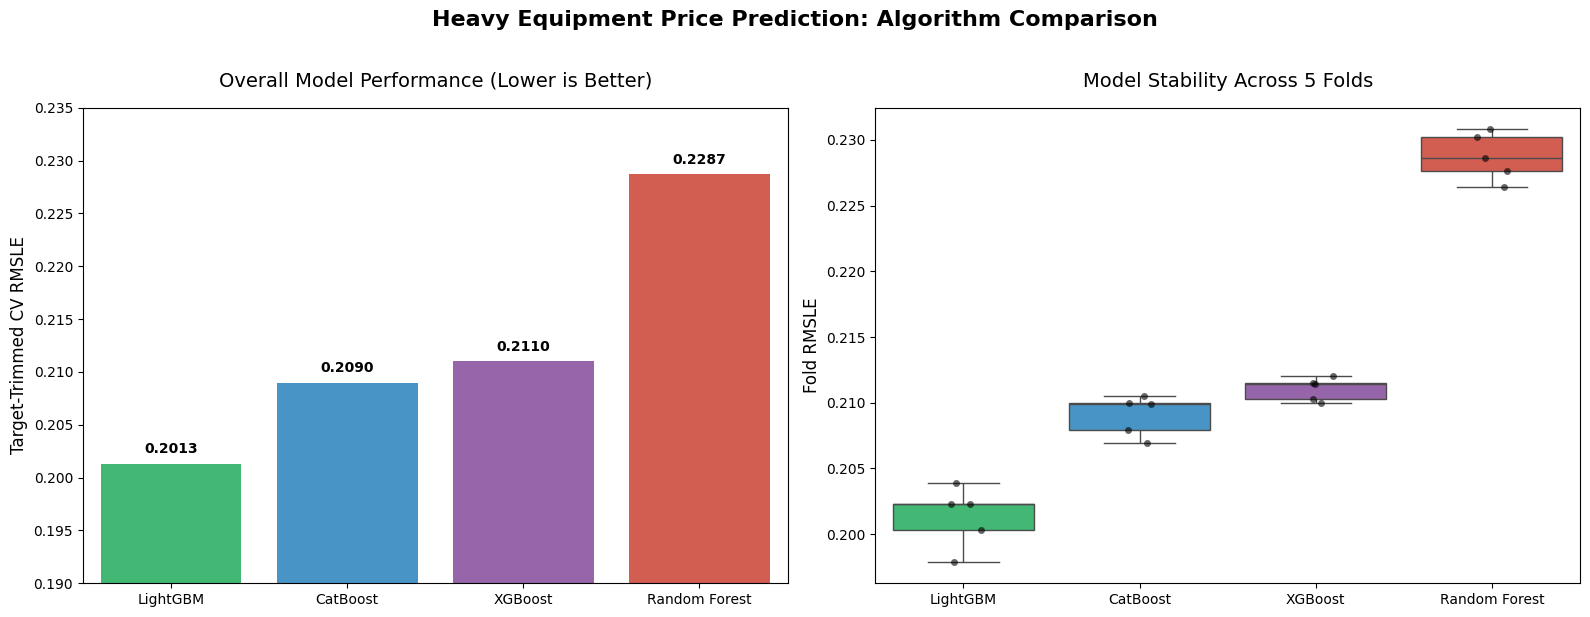

In [43]:
# overall CV scores
overall_scores = {
    'LightGBM': 0.2013,
    'CatBoost': 0.2090,
    'XGBoost': 0.2110,
    'Random Forest': 0.2287
}

# Convert to DataFrame and sort from best (lowest) to worst (highest)
df_overall = pd.DataFrame(list(overall_scores.items()), columns=['Model', 'CV_RMSLE']).sort_values('CV_RMSLE')

# 2. Hardcode the fold-by-fold results to check for model stability
fold_data = pd.DataFrame({
    'LightGBM': [0.2003, 0.2023, 0.2039, 0.2023, 0.1979],
    'CatBoost': [0.2069, 0.2099, 0.2100, 0.2105, 0.2079],
    'XGBoost': [0.2100, 0.2114, 0.2120, 0.2115, 0.2103],
    'Random Forest': [0.2276, 0.2286, 0.2302, 0.2308, 0.2264]
})

# Reshape fold data for Seaborn boxplot
df_folds = fold_data.melt(var_name='Model', value_name='RMSLE')

# ---------------------------------------------------------
# Create a 1x2 grid of plots for a professional layout
# ---------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Overall CV Score Comparison (Bar Chart)
# Fixed the warning by adding hue='Model' and legend=False
sns.barplot(data=df_overall, x='Model', y='CV_RMSLE', 
            hue='Model', legend=False,
            palette=['#2ECC71', '#3498DB', '#9B59B6', '#E74C3C'], 
            ax=axes[0])

axes[0].set_title('Overall Model Performance (Lower is Better)', fontsize=14, pad=15)
axes[0].set_ylabel('Target-Trimmed CV RMSLE', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylim(0.1900, 0.2350) # Set limit to zoom in on the differences

# Add the exact scores on top of the bars
for index, row in enumerate(df_overall.itertuples()):
    axes[0].text(index, row.CV_RMSLE + 0.001, f"{row.CV_RMSLE:.4f}", color='black', ha="center", weight='bold')

# Plot 2: Fold Stability (Box Plot)
# Fixed the warning by adding hue='Model' and legend=False
sns.boxplot(data=df_folds, x='Model', y='RMSLE', 
            hue='Model', legend=False,
            palette=['#2ECC71', '#3498DB', '#9B59B6', '#E74C3C'], 
            ax=axes[1], order=df_overall['Model'])

# Add jittered points to show the exact 5 fold scores
sns.stripplot(data=df_folds, x='Model', y='RMSLE', 
              color='black', alpha=0.6, jitter=True, 
              ax=axes[1], order=df_overall['Model'])

axes[1].set_title('Model Stability Across 5 Folds', fontsize=14, pad=15)
axes[1].set_ylabel('Fold RMSLE', fontsize=12)
axes[1].set_xlabel('')

# Final Polish
plt.suptitle('Heavy Equipment Price Prediction: Algorithm Comparison', fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Model Comparison & Evaluation Analysis
To ensure robust predictions, we evaluated four distinct machine learning algorithms using **Root Mean Squared Logarithmic Error (RMSLE)** on a 5-Fold Cross-Validation strategy. RMSLE was chosen because it penalizes relative errors rather than absolute errors, which is crucial for heavy equipment where prices range from $5,000 to $150,000+.

Here is the breakdown of the advantages and disadvantages of each model tested:

**1. LightGBM (Winner - RMSLE: 0.2013)**
* **Advantages:** Uses leaf-wise tree growth, making it exceptionally fast and highly accurate on large datasets. It naturally handles complex interactions in data.
* **Disadvantages:** Because it grows trees leaf-wise, it is more prone to overfitting if the data is small or very noisy (which is why we applied outlier target trimming).

**2. CatBoost (Runner Up - RMSLE: 0.2090)**
* **Advantages:** Built specifically to handle datasets with high-cardinality categorical features (like our `Spec_FullDescriptor`). It uses symmetric trees, making it incredibly robust against overfitting.
* **Disadvantages:** Generally slower to train than LightGBM and can be memory-intensive.

**3. XGBoost (Baseline Boosting - RMSLE: 0.2110)**
* **Advantages:** Uses depth-wise tree growth, which is traditionally very stable. It is the industry standard for tabular data and handles missing values elegantly.
* **Disadvantages:** Historically struggles more with raw categorical features compared to CatBoost, requiring heavier pre-processing.

**4. Random Forest (Bagging - RMSLE: 0.2287)**
* **Advantages:** Extremely stable baseline. Because it averages hundreds of independent trees (Bagging) rather than building them sequentially (Boosting), it is very difficult to overfit.
* **Disadvantages:** Cannot extrapolate (it can never predict a price higher than the max price it saw in training). It is also the slowest to train and yielded the worst performance in this pipeline.

# Milestone 3

In [44]:
# import pandas as pd
# import numpy as np

# # ==========================
# # Load data
# # ==========================
# train = pd.read_csv(
#     "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
# )

# print("="*60)
# print("Dataset Shape:", train.shape)
# print("="*60)

# # ==========================================================
# # Q1. Missing categorical values in CabinType
# # ==========================================================
# if "CabinType" in train.columns:
#     missing_cabin = train["CabinType"].isna().sum()
#     print("\nQ1")
#     print("Missing CabinType rows:", missing_cabin)
# else:
#     print("\nQ1")
#     print("CabinType column NOT FOUND")

# # ==========================================================
# # Q2. Most frequent SaleYear
# # ==========================================================
# print("\nQ2")

# date_col = None
# for c in train.columns:
#     if "TransactionDate" in c:
#         date_col = c
#         break

# if date_col:
#     train[date_col] = pd.to_datetime(train[date_col], errors="coerce")
#     train["SaleYear"] = train[date_col].dt.year

#     print(train["SaleYear"].value_counts().sort_index())
#     print("\nMost Frequent SaleYear:", train["SaleYear"].mode()[0])
# else:
#     print("TransactionDate column NOT FOUND")

# # ==========================================================
# # Q3. Median AssetAge
# # ==========================================================
# print("\nQ3")

# if "ManufactureYear" in train.columns:

#     train["ManufactureYear"] = train["ManufactureYear"].replace([1000,1001], np.nan)

#     train["AssetAge"] = train["SaleYear"] - train["ManufactureYear"]

#     print("Median AssetAge:", train["AssetAge"].median())

# else:
#     print("ManufactureYear column NOT FOUND")

# # ==========================================================
# # Q4. Median HoursPerYear
# # ==========================================================
# print("\nQ4")

# if ("OperationalHoursMeter" in train.columns) and ("AssetAge" in train.columns):

#     train["HoursPerYear"] = (
#         train["OperationalHoursMeter"] /
#         train["AssetAge"]
#     )

#     train["HoursPerYear"] = train["HoursPerYear"].replace(
#         [np.inf, -np.inf], np.nan
#     )

#     print("Median HoursPerYear:",
#           train["HoursPerYear"].median())

# else:
#     print("Required columns NOT FOUND")

# # ==========================================================
# # Q5. Columns with >80% missing values
# # ==========================================================
# print("\nQ5")

# missing_percent = train.isnull().mean()

# cols_to_drop = missing_percent[missing_percent > 0.80]

# print("Columns (>80% missing):")
# print(cols_to_drop.sort_values())

# print("\nTotal Columns Removed:", len(cols_to_drop))

# # ==========================================================
# # Q6. Best imputation value
# # ==========================================================
# print("\nQ6")

# if "OperationalHoursMeter" in train.columns:

#     print("Mean   :", train["OperationalHoursMeter"].mean())
#     print("Median :", train["OperationalHoursMeter"].median())

#     print("\nRecommended imputation: MEDIAN")

# else:
#     print("OperationalHoursMeter column NOT FOUND")

In [45]:
# import pandas as pd
# import numpy as np

# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import OrdinalEncoder

# # ===============================
# # Load Data
# # ===============================
# train = pd.read_csv(
#     "/kaggle/input/competitions/heavy-equipment-selling-price-prediction-challenge/train.csv"
# )

# # ==========================================================
# # Q1. Preventing Data Leakage
# # ==========================================================
# print("="*60)
# print("Q1")
# print("Correct Answer:")
# print("Before applying any scalers, target encoders, or median imputations.")

# # ==========================================================
# # Q2. Target Encoding
# # ==========================================================
# print("\n" + "="*60)
# print("Q2")
# print("Correct Answer:")
# print("The categorical feature has very high cardinality.")

# # ==========================================================
# # Q3. Train-Test Split Verification
# # ==========================================================
# print("\n" + "="*60)
# print("Q3")

# target_col = "TargetValue"

# X = train.drop(columns=[target_col])
# y = train[target_col]

# X_train, X_test, y_train, y_test = train_test_split(
#     X,
#     y,
#     test_size=0.2,
#     random_state=42
# )

# print("Total rows :", len(train))
# print("X_train rows:", len(X_train))
# print("X_test rows :", len(X_test))

# # ==========================================================
# # Q4. Log1p Standard Deviation
# # ==========================================================
# print("\n" + "="*60)
# print("Q4")

# log_target = np.log1p(train[target_col])

# print("Standard Deviation after log1p:")
# print(log_target.std())

# # ==========================================================
# # Q5. Ordinal Encoding
# # ==========================================================
# print("\n" + "="*60)
# print("Q5")

# if "UtilizationTier" in train.columns:

#     temp = train[["UtilizationTier"]].copy()

#     temp["UtilizationTier"] = temp["UtilizationTier"].fillna("Unspecified")

#     encoder = OrdinalEncoder()

#     temp["Encoded"] = encoder.fit_transform(temp[["UtilizationTier"]])

#     print("Original Categories:")
#     print(temp["UtilizationTier"].value_counts())

#     print("\nUnique Encoded Values:")
#     print(np.sort(temp["Encoded"].unique()))

#     print("\nNumber of Unique Integers:")
#     print(temp["Encoded"].nunique())

# else:
#     print("UtilizationTier column not found.")

# Milestone 4

In [46]:
# # ===========================
# # MILESTONE SOLUTION (Q1-Q9)
# # ===========================

# import numpy as np
# import pandas as pd

# from sklearn.model_selection import train_test_split, RandomizedSearchCV
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import OneHotEncoder, StandardScaler
# from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
# from sklearn.neural_network import MLPRegressor
# from sklearn.metrics import mean_absolute_error

# # -------------------------------------------------------
# # Prepare Data
# # -------------------------------------------------------

# df = train.copy()

# # Fill missing values in UtilizationTier
# df["UtilizationTier"] = df["UtilizationTier"].fillna("Unknown")

# # Create PriceBand
# df["PriceBand"] = pd.qcut(
#     df["TargetValue"],
#     q=5,
#     labels=False
# )

# target = "TargetValue"

# categorical_cols = [
#     "UtilizationTier",
#     "DrivetrainType",
#     "CabinType",
#     "AssetScaleFactor"
# ]

# numerical_cols = [
#     "ManufactureYear",
#     "OperationalHoursMeter"
# ]

# feature_cols = categorical_cols + numerical_cols

# X = df[feature_cols]
# y = df[target]

# # -------------------------------------------------------
# # Q1
# # -------------------------------------------------------

# # Stratified split
# X_train, X_valid, y_train, y_valid = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42,
#     stratify=df["PriceBand"]
# )

# price_train = df.loc[X_train.index, "PriceBand"]
# price_valid = df.loc[X_valid.index, "PriceBand"]

# train_counts = (
#     price_train
#     .value_counts()
#     .sort_index()
#     .to_numpy()
# )

# valid_counts = (
#     price_valid
#     .value_counts()
#     .sort_index()
#     .to_numpy()
# )

# # Non-stratified split
# X_train_ns, X_valid_ns, y_train_ns, y_valid_ns = train_test_split(
#     X,
#     y,
#     test_size=0.30,
#     random_state=42,
#     stratify=None
# )

# price_valid_ns = df.loc[X_valid_ns.index, "PriceBand"]

# valid_counts_ns = (
#     price_valid_ns
#     .value_counts()
#     .sort_index()
#     .reindex(range(5), fill_value=0)
#     .to_numpy()
# )

# valid_props = valid_counts / valid_counts.sum()
# valid_props_ns = valid_counts_ns / valid_counts_ns.sum()

# max_diff = np.max(np.abs(valid_props - valid_props_ns))

# print("Q1")
# print("Train counts:", train_counts)
# print("Validation counts:", valid_counts)
# print("Non-stratified validation counts:", valid_counts_ns)
# print("Maximum absolute difference:", round(max_diff, 4))

# # -------------------------------------------------------
# # Q2
# # -------------------------------------------------------

# cat_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=True))
# ])

# num_pipeline = Pipeline([
#     ("imputer", SimpleImputer(strategy="mean")),
#     ("scaler", StandardScaler())
# ])

# preprocessor = ColumnTransformer(
#     transformers=[
#         ("cat", cat_pipeline, categorical_cols),
#         ("num", num_pipeline, numerical_cols)
#     ],
#     remainder="drop"
# )

# X_train_proc = preprocessor.fit_transform(X_train)
# X_valid_proc = preprocessor.transform(X_valid)

# train_sum = X_train_proc.sum()

# print("\nQ2")
# print("Sum of X_train_proc:", round(train_sum, 3))

# # -------------------------------------------------------
# # Q3
# # -------------------------------------------------------

# rf = RandomForestRegressor(random_state=42)

# param_grid = {
#     "n_estimators": [50, 100, 200],
#     "max_depth": [5, 10, 15]
# }

# search = RandomizedSearchCV(
#     estimator=rf,
#     param_distributions=param_grid,
#     n_iter=5,
#     cv=3,
#     random_state=42,
#     n_jobs=-1
# )

# search.fit(X_train_proc, y_train)

# print("\nQ3")
# print("Best n_estimators:", search.best_params_["n_estimators"])

# # -------------------------------------------------------
# # Q4
# # -------------------------------------------------------

# ada = AdaBoostRegressor(
#     n_estimators=50,
#     random_state=42
# )

# ada.fit(X_train_proc, y_train)

# variance = np.var(ada.estimator_errors_)

# print("\nQ4")
# print("Variance:", round(variance, 4))

# # -------------------------------------------------------
# # Q5
# # -------------------------------------------------------

# rf2 = RandomForestRegressor(
#     n_estimators=100,
#     max_depth=10,
#     random_state=42
# )

# rf2.fit(X_train_proc, y_train)

# feature_index = np.argmax(rf2.feature_importances_)

# print("\nQ5")
# print("Feature index:", feature_index)

# # -------------------------------------------------------
# # Q6
# # -------------------------------------------------------

# N = X_train_proc.shape[1]

# weights = (
#     N * 128 +
#     128 * 64 +
#     64 * 32 +
#     32 * 1
# )

# print("\nQ6")
# print("Total weights:", weights)

# # -------------------------------------------------------
# # Q7
# # -------------------------------------------------------

# mlp = MLPRegressor(
#     hidden_layer_sizes=(128, 64, 32),
#     activation="relu",
#     solver="adam",
#     batch_size=32,
#     max_iter=5,
#     random_state=42
# )

# mlp.fit(X_train_proc, y_train)

# print("\nQ7")
# print("Training loss:", round(mlp.loss_, 4))

# # -------------------------------------------------------
# # Q8
# # -------------------------------------------------------

# mlp_a = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=0.0001,
#     max_iter=5,
#     random_state=42
# )

# mlp_b = MLPRegressor(
#     hidden_layer_sizes=(100,),
#     alpha=1.0,
#     max_iter=5,
#     random_state=42
# )

# mlp_a.fit(X_train_proc, y_train)
# mlp_b.fit(X_train_proc, y_train)

# pred_a = mlp_a.predict(X_train_proc)
# pred_b = mlp_b.predict(X_train_proc)

# mae_a = mean_absolute_error(y_train, pred_a)
# mae_b = mean_absolute_error(y_train, pred_b)

# difference = abs(mae_a - mae_b)

# print("\nQ8")
# print("MAE difference:", round(difference, 4))

# # -------------------------------------------------------
# # Q9
# # -------------------------------------------------------

# valid_pred = mlp.predict(X_valid_proc)

# valid_mae = mean_absolute_error(
#     y_valid,
#     valid_pred
# )

# print("\nQ9")
# print("Validation MAE:", round(valid_mae, 4))